<div style="background:#102c28;color:#f4f7ec;padding:36px 32px;border-radius:18px;border-bottom:6px solid #d5b46b;">
<p style="color:#d5b46b;letter-spacing:3px;font-size:12px;font-weight:700;">KAGGRICULTURE · PUBLIC AGENT + MATCH LAB</p>
<h1 style="color:#ffffff;font-size:44px;line-height:1.1;margin:12px 0;">Fieldcraft</h1>
<p style="font-size:19px;color:#d9e7de;">From a working farm to a submission you can run.</p>
<p style="margin:24px 0 0;"><b style="font-size:36px;color:#efd08b;">2887.4</b><br>Historical public submission rating · checked 21 September 2026</p>
</div>

A compact release of a previously submitted agent, with an offline build, a complete match demo, and diagnostics you can reuse. **Run all cells to create `submission.tar.gz`.** No GPU, API key, or private dataset is needed.

| Included | What you get |
|:--|:--|
| **Play** | A complete agent that produces farming and market actions |
| **Inspect** | Cash trajectories, action counts, and two seat-swapped demonstration games |
| **Submit** | A verified archive, SHA-256 checksums, and download links |
| **Experiment** | Editable seeds and a simple opponent you can replace |

The **2887.4** figure belongs to original submission **56258004**, submitted **15 September 2026**, as returned by Kaggle's authenticated submissions API on **21 September 2026**. It is a historical rating, not a promised score for a new submission or a local cash result. The compact release is a transformed version; its packaging checks are described below.

## 01 / Start here

1. Choose **Copy & Edit**, then **Run All**.
2. Read the completed match diagnostics and download **submission.tar.gz** from the output files.
3. On the [Kaggriculture competition page](https://www.kaggle.com/competitions/kaggriculture), submit that archive after accepting the competition rules.

The build uses Python's standard library. The match lab uses `kaggle-environments==1.32.7`, pandas and matplotlib. If Kaggle's preinstalled engine differs, the setup cell downloads the pinned official package; keep notebook Internet enabled for that step. Set `RUN_MATCH_LAB=False` for an offline archive-only build. The agent itself runs without Internet, and the notebook never submits to the competition automatically.

In [1]:
from pathlib import Path
import base64, hashlib, io, json, tarfile, zlib
from IPython.display import HTML, FileLink, display

ROOT = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
RELEASE_DIR = ROOT / 'fieldcraft_release'
RELEASE_DIR.mkdir(exist_ok=True)
SEEDS = [2026]   # Each seed is played from both seats; increase for your own checks.
RUN_MATCH_LAB = True

## 02 / Build the agent

The distribution below contains minified Python source with shortened local names, compressed for a compact notebook. It is **obfuscation, not encryption**: runnable public code is recoverable. The payload has been checked before packing; it contains the agent and public route data, with research comments removed. Its only agent dependencies are the bundled route module and Python's `math` module.

The visible harness checks decoded-source hashes and builds the archive. The large payload cell can stay collapsed while you work through the match lab.

In [2]:
PAYLOADS = {'main.py': 'c-qx{S$7&a7vQt~E1ZXKs4~J0#Bma^e5R@>_RWB|a5#0ajU76+aRbisW%A$WE|N-BkfmqNJWThAsghJ$ukNm^$h(%Apx17P!6>SRgHfa1_z(^<yOB4QnTOf*HoBc%uUDAxL1z53M!ORAz2WF=5MtVu%sf9#Z)Q+z`VA8<WoG^~U(crx_;vwxOjqk@wVplW`?<{g^D=!}&(~D=OlH1J*Rv%)k7VY0zFdFA=b_AeoIl;q@Oc0&EEj*zZq~C~d_R?$VKImnpYWv*T^gKqgL*XV_ePk~lbO}@GZ*d3Of?KE_}GDtET*@d-p1;evsJWSs9v|Qq#8WFH&w@AT&7F|8t(LZqk1EZhV@<_)9NzQ2*M~BgkHxa)@0_+{;(=DH;c!|`C5%2g#7t(wZ`WPbY;5yJma?jzg({85A***1urm94|-mGocyb(?R9B9p3FQho@SKw9>z9*noVgM-{C;-@#(G1TzP|TG#vGKt&U`7R4Cxn8=1NAM!d|2GE*6F$6wQ8KCR=`EXqv3@!^AK##VqLQ(mOJ%y6my%FN5t!{X)>d<Uz0yM!tbV7|dp{IkS?eYHxgJ}#ay_lwM|7hj&>=`&2eH|T_eVbt*ktq|AoMP@o-yVr%sHIIDAE4kt~uiNN&ZFpbGOt&`})#33USfJh+JwC$#!y#6*keSe<rzcp`#q!f^iLE~(n0}r;trtri!h_7zy}>zu@=0bs&7W|o{+5|<^VtI~#hivTmzi3xH^k}u2s1Hzx&<(WmwT8eSQ`BL4)@aqJj|dwqk(tfhl9Ztyx&rp0KdI~ta=#YjKcN{Yc+V7;#3E%Gfae?w)#lG0{iQt*TaFr#_BZMEqH=WRd3Lep5xw_-^{RUu$OL@3*2R}lcrDeN7{iyp056&S2+u?dxLo3bNcR-7X2G-LfB4$HyF@Pf{k=HT|Q!wE;aKRHUzxDP6Du`PhlU8dL3`ngJ;-5YLmm>0R%CGr-rqw5Z3BkB{c<`WEi$_U{yI<zRY%`P*$f8D|moCaZwLF>_mXu<LMR~^JNzR9^eije+tV8aCNs_JnlWtm&?U6LcradKRz#(>%EcJ4|mm&hcc>&s4t?nh-M;s5z)1XE=6=DqQ<UT^ROZ@k5jLy5Pq<W+vlw;&~G8H9*$&j7Z)M|ECi3V#j1_La3rJ9dW*U}EG47rE~2ac0PqC9RJ^Mr2|MI|<`fPOMd9e3i)n9l+R-~vcweNnLOv=KRC@6+FN*J=ELL{W=vI0cI;U_Xibsd8>J;o#7_wIsfSll8W49dwl6kiaJ0Cj;KT&uIU@4FC^wRMzhms#hokrI@0wRCC%d5+kMpOe<{F#bW!gk|49MAv}%uUmM-87c$_M)0MsD#~U09z9$I>a;_MIr%fj1$y1avb@S-AeJje2;&jNw3mwbVK>J@QxC?p*IL|=BxBt1Dqx^_tWL=4DibB>~1f*h2+JP<Cb=J=68Efi}fB9EG=j2m*vwQw1lbVQ}b=fld22j{G_Z(dwcU0)e!l60F!(7v-NbnUOJx0+|F+1NLxe{x|oHftn6z>eU!bsqZ{Ww!&=JkQKjS*#i2NI0rK$iwK#;wmy%P+i$W37e^6nBX()YHLRh^iA-K*<(e;mbtbkHs2+p(kM-BNO7{M#~41d+A$I)U>rJrE(4EEe!^gL0e3skxgm;Pr@rJrCjmtIcvFvd}H61TowysT#q{1J=ml|X!ey*QKjRPIVhEH@=&mwU21j(U?Z{5_pa%Ga_tjyjX_xqO&CIoEF4m*;=|RV?4gGx#|y-%7{N6$Jcqh2!gAOyPI8d?B6g0Zh3QdG2EQ{fEmh=k!wU%g6bX12ZVFerPM0xNiAxIbOd!Kg=+pK5-{m_3F8IizP1i(;gKam-^7h8Fsll8ApRjxh}u|*xkWWEiA<w@f^oWiS2YEPHp={GTgM_p>(qV;{F6^4>ALJJ#J0L?TIRh&@*4npH}PX)6L8Y#O?fM?Iu2fQUQ<flPhI(PmS!HN|ku#mIwOzZ;^K?7rr^gjwz_)Pj)_uOYtC8+W2%*zLGaN^{Mw--0-*f@zwFCL?3o`hSIsr7F<}OV|jHfFZVR;>+hSi8wSS@<vTgZIt2u!;U2+IKCbxgSmskTKguGOy*jz%(uHz;+!n2geB8g=f1G}G3gUv=I2Et+t}BN0+3W$n8Jx&MNtGU?${t}^-1Vxg>gR~MY0Z~aMKF&3o+PT#8<Achdo*#yp{}?pf!{h<&DO9drY{d`CxiQ9x?0WepE3gAlEH?6>tViHJ5>S@=u36%O=#tx_Ue0B<fLD^ojp+c?oKGjO@z`(mcD8d2$#dG9ODk0>^uEzA&0;ny4(cdor()}&7NL>-~#D({-&0m<P0i=_Pk>(K67z?VT;_$)yt#f@A0QTe)@DUU(X&_j*F$SUz()4<q>VDTk&c3O+HK?uWzS&)6(>M<xByi<SOvT&GKsjUkkY1K1fU%B@2v90iK0>f}ykQhZAXI{89*=26EsXV%I-NnP<4Lab87?+;a8cdGQPbhyW*8AXSr9S}spDQ$t)H`LqWXa)k>?BlkssBd=N`_g_iREq7$(V__`R5Y9(2bg^Jv7cA*5*1(BcB*A$~BX1-}-Y_FCKhtcQGG4Nbhh+@V+?vgNmYrsuqP3+8Zua>kF>8rl%%zi?ijS_Mc#3w?r_RT}oN2aj;0jZFhi3>OaemT4^3joV(NM^zQ>w`h^s9`}DQniGGJ(`cuO?;1tlb-2yZX2`QFLS+Jxq8ju4Y^)xtulZ4DHkVKVAP_yEdXtJG5<Nh=iPW4LlY~uv-jWZvy|(?KFVx9Yn+|9qxJ+uRr1!Ak)zx1aY_9=++2QT;QrlNC2YXY=FN+{?@?20Hc9)@6O^jfUik$8z6`6seKOhsLg+O3@n^oa0l{WxJMJ(mW4gD{wzOXJMOsjdZM?c#e%uVQZsh6nKWy6{D)PgnLbq?vV`1O-8HN{W|QKzkJAnSt|OS9`OSPSw<l)}M;dcRs{VLlpBI4h(rm?m#My|2k#dc=3m>@)J^2n~(+nU=W`cC&x_XvjJJ*RZAr7N0Ys8S$m?7!NHZmksQvs-3{a6+YxK`aXejf;e33pfHhG7!xb{I8aUQ>9<ykU$sEPC%Ty~mDwnw$fTZ|_+t-fKt#(CQvcZ*Lu_xq&^v&c5f)zKuJJALw3|t8(mHbi`*m(vsu0mD=XiKF*2acq+u1b&%Er@^>o0dsT=FtLR@$;deb3fe4f1Wm>n>ll^gk;1&=G>MIhY`5H=W(fC6ebC1W|M#7w@6z0=fPzyFNGGMM`5;Lo~>tX7eh{e?NEfr=;dBWfk64R?Dm>a_+Xbu^ZDzpNq<Q64JU<ca(9cfPNL~@s*72E=$ZjQG(tkxS4hgu?f5K&V^_aaki)G|qi4pva&c(_VhP=zGAiE<vG-Nt0x)V$&^;f8s`y$wjx+@iOILp+hMvHS4LlT$yD#iE`Bjj#Wt;midpY;+Z`RTVUJtc9RZRuL@|5W-`j#2ZdQ-G|A>y5p2gpT0RBkBL{brd|pY+9d|PLABn*Ezys3fKRI7625=`9>9F;rOF}ln*bUt<c(+p7=jQ`j3pK7z-R8-7hBf&3NK@Yw7yNbnD}Jy&99K}Cu$$M@4a=og2(y8r+-}mCdXO;RnzL_n$%a$i&%Y`66W+IJ{cPIqFZ>`-FcCO0bUrJydYi&0G^8I*46vwMemyzm~v>*E8&Cm#`rTa-$|`44tl*l!9g_NQ^g@S@;;b}exaVC2FK9|UfexQ?^n^{4)`wYazp9_Kt+h@0~RW)GT39Ti?|hH3K~ERPz5wbt|}mr4_{rtQxg&go3aYveRznYaCogMq6l0+>30zPV?7QN5T5G_0tgHY0OsvP!K1UG@-Ya;e5EHWu7)PgS}H`r*r%g+TrkzAw;*vscJVNu$bPM|3wfYlm|r;3+r&vISr|dW92}5@9`k8#vO46eD22d}8_>Egnk@XvsIzdQV$ynw+6@p%NHm5eX;MuANu1u*5wK*@9W46|WwsKTZ<CqzL?&s$u)y3DXvYO&br=@8fg*PZ-`}Hpi2%9Ay{qHi1a=UFw4gMm981bqg#y~Z6TsD_@q`BvmOR2!@h+lwAZ%riu-4ehfmBl^<-%s@NFqKh{8MMy&$pWNs7b{H;^ZbY13qs?UkNQf<GU4&-e(vJOZWght<Rf}k+UjU(`>lU$nlynddZiB46g_o8jP+AT~VRVuM4rL-`0gLbs-ON>B00FHRIH87B+ajPUO*h2GCe7M;}NV9eWxbTLkn%L_-m+-ANYl_yx$jTA%Y4#hE}-%_LK(Y>?OU0t)2f0&ls%gqE((;(=a8B}8x5${*1fh|-&sJP!`o_G1|w7vH_JcV4W`{LRi&QbR>l-IDIrJ&-A$0C*pliiB_=amLCwN{;&-m)<P7mjcJKn(cA4MpEdFixWN5u%>I9j?VVBRN+lx;^;ATxt^|O(e!@yv?kOIz<W2pXQf}}Zu*!3W-+sx!>>nJ`~G2ZJ$=}VB`V<9=TEe&S`(g8ACOQfEpn9+&)huBrb`gNc2MvdXP~|ekexEU!ROMa?_=~t+a$({fTAqH%R;2y2Ilh;n6K26j`wrrB8w}h6B>x(RWE^Off}roD@@tl2_%s@)UYHrhrexe1k%!~2Eu&gAHOXWac}pv@?~98)vja0snJGKx=ksu{r?mXX~JO;qlvs;fFvEkg3TYM%lY~nw0-?T$dZP6Hj!NLL>|0Fl;$5FzWak#=uuIMGZ6u>pUUJ1T5vy=XlQzf$nyMgv7G;Rfy082MPK*=i;8=YC2m152S#BDj3+*QnLphwzQ_V?+*o>NAXfDUk}4%z7tLm$s`bUGAO$_vgMukp)MQbh;Tjg@jUZ#K%nLNlO00|w<!W~0#%K;R%ZD}8F#8OkiCnRRT#EF?{OL2l(>5AMk3fppbjQiR05B}L_*)tyc!Z`wn3I5n&Ok1fx3eWI)Rz^FYBdFUIO0CTi2iw5tY^S&4P0QEVqu!0NvlAD-JKRNa3}zKEC92-*FqtfWWMv?$$aI39Jg48Y$38K53xceJ%(}|a9%)p@E+P)$k1hdP;+9?4Xe*FbKtrYR%uqnMN*&~kU)7UhvO<%R;9{@TBX^R-@Q^oqj~u=ji%az`5)yg*aM3Pr%m`7aZej?!}qB1gO~e?NNOFVwTp5`bV+e{ZmU6`NezmIm0X>bcxX1sHH-qZqtm;PsOa;DY~fhGExgb97Um<-z6u-_3{EPmP3NS(rwumv`bzS<GShTV8hhG8gRie-LuGr1hB>Gb1~ko>4cacLmQc8?$uUnl@NskIpNXCJH`!@-3oFCSU(*)QnlKFt{nkn~%_B5f^;<ibeO=?bMR3g8&|>LN0gMk`o^NsW*_KSIJwaAtQteFyn};Pyd>(NoF{d}NV4j@~qP{oqIzwfIdm|3>c@cdR2k(Fnd?yZyY?6Bo8E+uN8;ZgK<-diDcF8%)i(;NL4h|^;jd-(?Qz+&|LDlsZ^54UUM{Lw9LQSvfBWyrqR{vzgYs$PXIhgmlXe!iwxP%&y&=^?cMywjIpvF8l_9j&$e%C-7qVD5+t`dLTAG_>B5j9333_qHS=uQBG?FB(N97^X9O_0tT`g<te(DNHDQ+}L2!~Bb{Vnn)5HoHGg*B|$$t39v$RU!j+kQZN>VBMi;Ys{`+bsBclB<`E!=$lUT4$y(bv1@r3=RGX$ox(vDbA9>suaRC^Kl|=rUv<FG6%O3}{UY_70fP~|gP1@V9}pZyAkAyp2gs?2ng~T*Cg5a@-?5Y%9K+1!^QEfvv$cKyFEuR{_|$Xv%^MZU0m6lT5{-lMxq4haOq35rkfSfCyc!XkpOBjXUf>C_g3BwBA_~ZY0keREVJW#PD}>c6jMZz};#vKv#k0zsVjVwJ*xP3kRncl0(icKANzqE_4ox~sQ_2_>rd6M<aS0Jg&7HWG^y48<Q5%OEQ7|mpB2h!uAsZz#!u9o7cNjCW-l3&(C3{Z8m}&fR6BtG6VG}sAEDH)avrJA2Lwaddp{FHyFGgba?kNR|i!Dx&w5U&t+IH!W@jKnF$GXKVYbW9kH0)e=qc_t;Z~m}Fu07FiE^t#CE{iSFI(FnHqv;wrEY`*-PVC<>N>PX_+mx6K>;!3R0y6%i+TB*6N8S`IqX1QPvffqbEi@E};4(nINrB21^`Dslvas9ZJ;@U^RO9(7pAy-wiWbijw9F4Vd0MW*A4Qd`X}h#X(k|6oMRFQyDu!E?Iw+M#$uUg@LUZM$$v+Z#_L$!qP#>D2lGStTRQ~$wZ82ML_um$CWGbiG<|S=13LG5EidD&(+=2iC7r8Z~queI4w2l7)&29Mmc`daSM70wzZ02-#=K{DbNR2DqOV>F3QNBzT8V42*(HJC1;E!}A$!&oAnsMUFI!@FO_yqzWm8*bw1CkXRIhAFc6);z7%=B`xr;{)7>707tqXEFcc@hcnzB)7Ia&7ad<bp;Dcsc~m)P61IZ!6h?7{HPfh<2sgc7PUXnLfyIcgqBIQwWyY+fa*7w_`6U{g}o2;FhkJv+1W@a^|qLFkPFeBjvc=j#|&{l@6^+r(|<9P!gBfixJzF4Xo;P%RSm94TUAAxjJ>LCNx0PgzG8jl{$JuLXjSD+>M;<sZ3fA-LF1%%Tp$QB267PCPRID;mEIVC$(Ar1PiG_lyKxR^2zqg=&x4RUD0-8U8}N8$wCtK7*vB8$QS*IHnP=3mAYT5+bET0XzWkqwh7Bt4YrDzVI%};>7R`rikCn>0+2F2oleSCQ3DnsoQTS}kPDe1Vuu!noc}U(zLK^YRwZf-c92IKtS9r#Bq-;L|IVMCu?0_66hh6u^(Mm3tfew(CpDzwYkQX>e$mKvlU6IAtyY8?BA*;an$j^2R3iAvcfrPYYQw*h>K%n9^HTD%vQVyPWkbrQA-wg!JlX*#@*U%Mn2K#Hp!F}mScryb+6w_J-|r^0@v8}KZky2B|KWtz|8FL=W>086HKEn4tVvln6I$Iep@a5F3pecDt6Y0&rnjh>*!E=cKEU{(epB2`pCw3hO373_B<_b?!h!oS+9>9JitpZOhUmyBsE8FBN>UDyR<tkavvNaX129k8q*eBqQ>rNUy;z@w;29)5%P<R-pkl04r+vmdN~IT!hnosL;FwS3!F%RXm_(B9RC+n05f1#i|2cfc>QH_w!fWw06{ayBW8q^QB$eTg4z=~WPY^Q#K3yrgfZeKV(V={%-4dDSQ;3yd%`6w8!hxc(l`$Rv$V_5ddm5wuGP89fKy_{opP)DhahVAvI0J+U7~pyQHIPEf|B$#mvzkcz2Pb*5f5$99iV18<w6+;<Fm#mC)Z9bBz&Xn@sED_Pf~%?f&bdus9Zl*x?uHJ9$Suff+ezp7pOH>&(8ndIr5wTT_F78c?Jx_|NzjKAS;Hx)9@k*?V_Lq`%95uSS8yz=*+Qu;J2?Up<$np%ttn52y4WkIX=t;Dj=Q2N+RA4I``>hr4R_o?cgNLY2^$0ok6*_;Wz!X~6=uuT3^trw?!q$QZ16VYbw$q&X7hSUH6kgj6w?=udy^de$rdKZvQX+uOwc456=%vlFz%2gh&O1J0VjwqtgXAtj#9m<{Elj$r2jiBZY+0vR@X${Tfy3%jPJF=!BqzG`mAZn^utjUc-1h&-?!EGpWPq3^&XzSqN4=Z*ijy<f0xHPN!4^+D!yTVw2zC2+vx6Lu~;Vjro?iwc$DwnDBUvvpp5He3S)9mT1&W8VFd{>#z%iw)RAf|zr`QI1whu>+eDE%de|!D&>)bn9{^^4nXMdmLkRT$g%IemfwW@uo7Mk;UDd0lL_f@|*&@wxg>x{Yag5VtZ=Qt2=O=k67N%!kpBJl_<&3Ba>6rdme*-eIzWFHM0r8TUhLeiqn-S#LGrov8{)Cpw6Mi<J%^$?z3^lrLZfjX;=qF!L|14{P0gSB{gR1!W?S4Lcni)x+G8C<<k|YlTaoUz%HQqD?GpY_;Gh9mm22$2w@d|r`C{$5NFJuL!PU9X&s2$MYhO0PzN-JF}h2z>7UnUdHawk$)T%~FfE?hgRjAS&CV7JMc%~N8%HBs8tKS&}O&o%!3-Z+@h*^4NNetj9>&zFz$hZ&k26tMcaf-Y_>$tD$T;6o9uT&paid3eMJv>jubz;{X%oKW_2vcTRL*sWGtT~J5i0Wwi(Hemc2lj;E3NYzhv%Ja4kE<k?l=Oa{Ks-91@XM&%_o*}Oeb(Q>yCH^G!2#p`Eq?KvlFtMnn4Gr7wvMlAy)~kypZe~Q&q%*}87pxRoYV{hlwN!36wtClQ4g$0&6Ff^#Z_w&)-D_9n8>1%2SD<J7;|h9DzNuV04~Rw>jT-H6sK+uU6IIIkMdge8^o3!QHnZk;^zkccH84rqq@36&g}Jd^ihG8S0<!^0*zUjjycav-s-s1Vl~~`Cju~2&@LCQ;MM4rQ#a~G;dD192@%9pjj4H3BpFCbvIq~;?ezFLUw$4`TXnF&LX@wmy5+w0kv=TqD!9ii;O-}>H1U!yFRVyFl==z&Ou36%C`b`$!n(E;-i)i*pIh4SA&UwA>ctH4JeO=467^}9aCReML?CIo2ZyrFR10Kd9&t-J*L;Hn-14=`>hY;_h%@&ZR7U<Y?#{j@4flq*MD$>h3Va{{^`pcx|s%R(EemG;VR6(~FSuu=EuzLdx{AzC)juwy8^#c8cX|f|cy&Xj`EE0X_JTRUHmW6i$4^4x#^s)r8$M)<-Th{gbUZRBzext?nvqUr6>T&w;Ae}-{ymmn-THep#<p?cGu%Zv&q*D|HSC|9hz*@WoDe5bVQ@&8gqLD>;EkI6tiWYZwK*3iM7=seXN?17%Qq#k-caSKC)ZR{j2{^zpvB>2e#6$DpEgqYBf>e8y)-%=w<As0xL?c$ekiz2*utPLx`U`J7YWfRrJW~3Ly;&~k)HU~;*Vxa#1(FUj1a=*Dnq1(!O3(kG7GRF7p=1j>QN5aXnqu>W+YWP2Wbr+#N8zpL?iUYpMVyX!_TxuLC-{^adyPTJ%%fisw6LB<H_O=<VCM>$aKBu<Jg=kycJ(PNIAlIW*E4`;U@dU!p`+1iHhYpe?CU2!I1f@5<nXyl(!kNyfd<gscuMv<*fsE^)VRmif|54(1aU+0y@+SSZ0o%G1_)^UQEXSF1sbCx@J7wqx9MU9T`XsJU{3Z)3;0S2OP)1fEIY+EO`Wc{;|+ikZAYa7+9B4l44a;S8F55c`lJb};V&Ml#DkPb_<ZuJDhK+-15BtSW`CSP5YIqD1Ks?CNx6rgE0bSeKLa0dp`J6aMz^cXq}-GVbsmo&@xEEflC`Koa=nQS+29&0oANKQi>F5Mw9VC;PmFCpXR9Z?qPmw@YvQn~l3m<0!!V<4dhE6U)8ToO6Zz&%p1CuNOq>cJ4<|B#8A_IN*7NaLUi{9Ec8n1Kq_RbI&<z_k4Q}t8g_Dd7W3~h_V%7$!YQ~JwN~taeQazg^R+kDs3b`&G^F#`Bnb6Cg$iwnbrbk=mx(JEUX)_!?AUpDtrk?2(M1RU}kVnj&Oyi7t5@8Hf*Xt+oJeAT@SkJ|o+osS=#m{EXJ0Ro{XnSCcXiSa`sLXJ}N-Dn;<yUIH(%Pedx4J>jcE^EZZ;-o;ngW+P-j*72<K|NCa@7;7_te{w(uN^U<F4i6uSMJ|_ZOIVgdRu^?Yv6Df|OP6uW^m;xD>xkw5IDU<~~MlsUzbe*|YLgvMWJj+<_f{2f91i0{JLq3nT*cj9ZqGp${TnH0MlA#kHu33(*&WsETv8=~T$c^+UD|FE?_-!gc$TgCA|BK)yi;?c0Y)N-g>Gb0Dofb!=?wxf1k2!w%tDl2$h4qax)P$?zF?9*!se7RV;gpFRt8QWAtY1&Ulqy96$)ImWhgh2deIR<oOz_5AZJdU;ZjXEK11)xmk<MmiEJ0CbI2f*6jRcNHlhU~9eV<G*pr|7Mv>rLk|_q&yTOSqJ0|y^80g+>YNH_<kx2`8??sI+h-$CDUAZ-7TMyKU)jg>>+d5E#$BX&Z;MJlm5bBahe8>kt6GtmxpHi>7*4K$4}h}pGhk0X$L|4P@fZ25=mXOT-)uemp#iCPNc>5XksvM?1D}cDlQ_BbhBr8%*ov-S50kic6-;(!dCC;y?bn<oh<92I`QNx)N>vm#MIJ5e=lhhArlQs%ibhDTxBJ0obTGm^8x{^#c@?5s&g~HQ$$Pbx7Zm+jftz!QG4r{^pUH7-8tQX#4ufZl^deHZFy_PQtnjv1Yy6#Y6Wg1oQx}|oj`!AXvhn5BRx`J>oV<L&<ZP=bj*ZJYZdu@ZbnkLP`)~JHm-ab1A4^*^w0&Y*UbjmLiX|)zy~3zmw>xmF|U<WA4(?P!G%6s*W+&iLE5ltd?THMH-HUk5(J*Tb5+QMwEm0Ejp&FAIs^$PT&Z9Nah-XqO7D%XlY3>e{nWwfZ#zSQEqFI<-79_)7_9mV2X;?dR)xPA58AfuYRFYaHEyIRW<w6Q4K{szaXTdN@kOJ6tRBm>tYvlLb=(dgaI{+TtxyA`L_}J!akBB(^%t#i(18!v@>Zx>Sc_1bwU=(;!)tLvxVUCqUvKu9Bi4uL4IaIAcY^`yeYQuW`LWySorjpaECC>)hAa99pYUN(0>LH^56>khhfnHY{N4Q8dD7aVf+*~!^`?-CS-$YHe)@RHm+8YN);J;exv6xbR8lH=uVj$aJ9)=JQt#xyGR{*<@8lm>V!ab9L>f=eFY7ui$uATlXdNa=T*YiEisE~hsJeVjKPyyV0LK=ofMZHu!i?~1bWpyZKgj}YDIlpc*m9^s$&1ye`7?|7jw`-=oK4q}&OgeF>)G^?bn!m%1FJ3S3>4SZFU!@eO~41_3|YOwnhowI=K8FwBJK=RQLAA0-Fn6*u^0G9X-9ZW=83+g(eV$w>mjIL)Q^~PV*BO|yO<nx;!TYxdc?{x`iS~uwFZD}m2!n2)EK%Vv%@OI_>+0TUCax%*t2_LbiH`F|A@|tu*V+eAVTHE3<HTl0hd=E8QUA!k<NguB(ty2q&Zg(5h#RrNR+OzlwFq{iX_lTMiS5_l7{xUO^dz_4l$&wpP+oLZ6prxY)R!Jk-#{lz*$=PIEq6Gq{0X(G>57Y?UJFSUfS|Ws|u+U&L-t^(GwSv3XHoGU31}B)^n&&cs)7pm73!-F;u5rFan+I3JT;XxrF%kaBEXjL17JLf-nfh^2!9-=TzVZv@Q^L6`QHf*~g+st{E3DyL3@(jt#R+hj^X0ut}YI_7D|Z%0|<Y1HEaSfQ^xta@^YL)!f=}x#ROFsQ?F;?A7ckuV%9hsYonsB`bO3DgaJJHmUZuA%N-QQz&*+CKeg7VjFmG*a-t+Pqg)t_Eou^J_m@<*@}bE0Wv6A%DQSr$Gpt2T@;%QC&!XX<?w9;Z%_>9J~Js{%9%Os8Mx`LJ(RfPY!1>HXmLR*Qo0f!Bt4BoRwB~rlUU9L(E(CWX>#SdVk5mU$$p@dLA>G=+Nza4ilU-k;b=~|Qx~PF{O*^K1J}Oq3GYQOwzM!8j95htkwD>RCI@Faex3-<Iha4)&b~U&u4}v#9bolb<(UIGVSFeK>AbE9LbLNfVWY0+H;=RR$Hgt9p!+E_#zam`m*lc!l%ExhsR=tNgRC&;0kY8)k&Sc)Y$%`<y&fAfNor7^WRc+5KbD+N`mX7>W9j3nAESJ!1Q|*=@qqb`XNVvG%@y7_1N%HPA#(`@B~ssGd3H+Q+xX1ViSp6{4=~Qamd+q^t<W&c$`Upp;o#}bdcJrPG`lnjFmy^{gSydx`bped`x)-7sZ-jvuo3TOC*htPBZH)avYXoT2<9rRhz0C;Vk`;ll?`C85U|%bfW1P%-e6#F(t^<$HEmR7xQ;<Muy+9}d>JTNqn(OR*UZvnqLWfp{uH#6yXD#5Et?RZ+AmetQgFvw>1<I{d4VyWY=j(zT4V;{<YJ32^V>B!P!QzfTAxa`<`eO4%Tpr012L4X0|uE&5?sn7JPsJ2q^Yp`#W_l>Zmwv6!l8Jf?vL`B<iZIb3lLf>#%}|J=Um|khJw_83@erw&;bF=+ud^U-`NvUBuLD=2#ciq##YYb>E{9Mu$v2m;kCFBm!c!CL|1$eQ;IUisEl1Y8<?WzC>edsxU+Xt(e#?~lB8A)<CXJ`Jro0Y<$M);jX!Um$Tm>OZ1HufiYiPiVWWm<igx?~Io71g)=*GCLxaLawz@wW*U+ADm316!T3~~sCK^OeTw!U;on8)D;{CIIjtT^<M>C6_Vtvv5U*G*7;zQP{?r~7DsG<$^Vrr%Kb*k|RXX<Nw(!v9@vpN=ZuRvNs6S2slU0AHfMf`J!0qg2A9G3|2w0FY!iBvu*fvod>QocwU%R0G$Dnl!n2(YpMD?4^5s+*u-ZglV-{v4v?1`)@&3N4>Z1d3pJ6u$C5;{C%248Np&Z+tYtBHs8d2CUFgR94a73j%Q)Y3gmYS}$%siRYK)%|{R%V7o1zUsw^@)yT9VDN(ul^w511kZPTgYTxqgJpav^0obHQmvbQoDfEi|ytLOCew)lfs(!NX7vS|gn!n5Fby=0kIoUW&VT&zlPh29gPdNHF?K8j#r&11nF#ND6t{h>S<u)Lb%0Y~t>aZ`n0#Bflc_8N3g5ydo3n8h+>~p{i+1g2g+({9E(!|F))vQ^9te*|Cjg$9pEMLnjnMON(LN|Uc$Tct=A@CDUV^8;6gZ;j91=uJ{LN^5;fTe1~cCR7&qX3WlTacOum3xyc#`4Sh3KwdX-B3@L8SMy1OTyiLC;Ntm*CUJBv6t;+D_Y*O24i;k_sA=h+9LAKO9A}tl%nv5TlTYPB+SZAxs{b8gX$FWGaV>Z#~&tHIW+~Y#f>-<XIQ9RYSPg$OmmeB`Oc|9EKV!ui5BcWp<-l;+=VMbfu}r~KAq_|Li(pR{rg<{j3`rcE2>;fyPTd)wg~Q;M4QOPuSLftn?#*L*~}gS7z6JItV$Bv>j>>_8^U3y87IN>iE+h>J>=@{@w*cHP{riKW1s(8k~H`-B$QuG#+R&`_>v%n^ccYhFuoQ-SWGJWczXYALS!<QQHUozZYgrnFq2)`@BHQXxe#~?0nZ|b^W}?50w*_O@aPKspNdeM4cuTgj^hdQ61xo}0`(ZLLT~UdQV<~is(V>kfhk502w-_)oLLv`pBmG(i>orGlMJ(7ek)-L6163;S%DQO!8=&JET11<R+Ne-G{4@=o`J;B58%#{RzZw2tWE%ySQcUzQD$jP9Wj2U?wraDdYt0<fQ%}X;iDd~J_<Rvlw%`7)<CuhvViLW*@7uai+ps+m;E>}Dihlt?kCXp7TY^IL~HYZ8=n~l0VouXuW-mXibxP7l{N-EefPMK3frb!8EYaMx|VURVg+ME^_HJyD_uo&a;e&Z00nx6`yg4WXX;fS&o*s*!QC86j6uf-K~qkUAx5uY>=+-$_1#!X2(?>8EWlW%u`^|w#qX<eI+@VA@jLoid^c2!$7&?h?ME&f>d0l|XGbozDTz+Aav@Z(_%{AFN1yThNUD!nXOug0bLYAD?{_u-m)8c6G1BG+MZ&)Zu}-_=Tj#RuzzmL6nwOR>u}MLq4I;9u@i&w13&p!$s%fmM18aFV*D#NW9@!#z8MB`CV@brPZHgTiQk-ay&+cuR^q)_=W%aG4&+gTM8M4mq#ptYO)yl9>C-|&_JHCB_uO{l6>u%;`J%;Ji6ilDulGkJY+&;xvQRngjd6Qk*Pnn}N0`t;n<`doA0UP8WfCIdg#KhE7IHqgMR-x=F9Mc6HQ+|*YJ^-jf3p`+Gbczi?cyy(d4_(Qt(><0X@RfWWzp3o&03PI#mLrcaHDs0Xf1$bEq1I$qd1WcwmUmytuw)uWw~tV01^4$KLfzyc&EYfk;YX&QkJ2Z41n+TVff{bF$Bh8cxcn4E0YIRM(I=lUT&Jv+W6D6oBf_8qyFnoiEW=A00Kk*)!xnvm%5msNyKcmdDs=?EOj5n2hBkWKJc++ZZXgU64tNjxPq0S;!!bd-a@<K1P9lI(Ib<Y8Qk&_GfeN6rqttP*B~$3PBI<}6$wCDM&nHUz(TnZoZoKImd<@NU8^HF+q}`a5xh3Td#pbuCxEj?1#YREVg6<Tsf9GN$o+YPZP|^!Y=T67xlkwRkp*6LY>K8_-exa4>ujFDce)nEO!n2(~3hxu($BHFxjUX$ZI+8%=j>-CUC!8~Mh(Q&U*Rr}YqCk|evy#=sV5atm1~mLHMo4wDWXy7FW=WAt9dAb&iYTIOoJJN_N}^X|!LdRU?DP{%MzHNXdGa{9rNJ_O0(*hI9nmfu+BuidhSA~sq{C17$%p%VT+?xoAH|oqh4-#IDgQ(CM)}ED+spLf(%s#Du>K-eWL}PkrTC<RpU}J6{rrHwc-ov)5&yU(7z1mSFHhm$Ai?%;*&%=r?o$j35u~`c<Uo=lVb-}3w|pfxx0TXIwPK5bs-)#&7+?yeVUx%fvull#uIwrocc?`jitXN8>lvo%$;xyE@cl;#^UBU+L*+bnsWHxS+cazjKrs_D{<u|z`*C}WiBz-%D~^KVR2y0_%8O<0$}P{O(FSUtK2#NyPDNWx$!#*Jj|s#F(G&NgV<OdSj_}$#M!H3haU=f5%23>_h!2P`v9C8q9BUkVn<|Jtsvxc{6-3YC{qD2vY$MxAsvTAvYKJ+g9oo4@uH)i8ERC$wq1YrzwZkf*cBm?~!?jyp|4QvJM~%Z^o7&;;4YkAiSeusjZ<X4i%4&yc_BQKnQ9GO_)DAbKc4)+Ehjvyr%G0d8H423n@j20UX)t~P<oVeYKr-<~e8ECDr4OueK;#@BT1OOlYHxiYxgRI;drV=og={J+U91v2b$^uo@h3b~XwWzip{#6MXr1pOgTw)_=s0~*e_~}@JQ5aaXFKHtR{@M-AK3=-PKDeFF%cIr8ap*^jrD)&@6ivt>QvJh&ojMApJ#d_-nkQjSw~y5CR9Uk6}0hu>rKfy!h<8xUCDVTFqYZ8<QziVCURNO!;2W8;2S*rdRL;*ZS&IWeE!ESUKgheR7wRxuEjhar^PUCGd?f-QhJyF|I<xn_;EIS?$4fn<E6s)S)tt=$a7v6*bfDxo+_7=FN?*4EW*SP%0anV9=<_ORp88zlHMt|)A_?U<C=jn$^>6CC!-sRf`HB7nFkQM1Z=ze>ElfKt8h6y0i%-DuR5}WfjQArL{;aj<1jBbYg%2r=8CVpqRXzvKAkVY2Jz2t-C)!l@DDqY<k75|R~{@h8~Q<|(X{9X?GHn<W1i6Sgr<r9ZuN6X&RF72`>l8vTO3#Twn!9sv>-(NQGvDcxGXm>Gn9M2u9wqDW%7$Eayz@hJ0Vw_ZY@BZ@8{QO%1a$736jRsko-5a?opB0fZR`BNkvj-MmRCyUcP6#7a5W1hVW;2k@=Ch)TH|R;~c!Qn>Weu=?BaMMlVq*2emx7S-d<U_x092j@OlMVu-FL$ML$Vw94efTGvF4itD4n0&xO>du3cojhXO`LSlXriMi>T{KRbr8pr`(E|%1apH4TGn&UXhI#X5;258OM(sWg1%oTGeDJysrxs*66Lbyks0ULqE@%RMyC+<yUD|gHK6}xJxZR64aUvpK->J2MBu4q0@acIdS3d#238}taGl^(<KZFARZt!!Euy%jRRx@C;cgKjuAy4BS>R(|ws1#4CINcqv1J)>alpRk96o{_4nm`*&@&ha!rP^qRw7`l7Ve1U6FeI<Qbygd~<#Xm5cGjtOI1c(d1SyImkIu-$~8bPO;5OjVo#GH=%*}@-*F%47&1BM70Lo|OQ;elL3VYW8JyQW(n{!aWlbz`j4V8&_iN)GMr)MRo_%Oguw-GaHbF8M_*FJCC7qMwv1<IY4@%f4ouy0)Sot3RVlLp&cimS`n>y+M6O`xH67rbEgrhN>ctG&?ofZ^Z*>x>@`=gH4dPM{u#Jiw@A4;V7$G*{@*?CE#oFS&Qcx>&{H}RXKORmOa{cI2I0|HsCVzE=HZg1t8wWOLJTla+3LUVLfLD*_M$Ed9~t0{|aZ=L$ET2sfdADE97F`deQyl2prf`BQ$z8Ci;V#>`C#|4G4*v*2$U@9~&0Ye2VVbFku&#nAC<P%a?u*B`ABb7*fwVzGedU3~=oENjAX!MO_LcD=acZURVP87X+5eQcYw&WlF6d<#WTzpA#$J%%15Q&KVopK<}%-FG5|(O(?N0)f)$R(FzvDk{N?dU3sPiwB-Z6<tbDu;YRj$6)kC)_82b96{UG+H%U@H8tDMNoZ=U)g!6Fo0==zG##LK===}1gp%HrTX<AjPB(?L*PS}?^rV6yB3Vmh~@g_QR^Wo^64$6K-=7<v&Gifu&{STrP)9ZGs9gY1{=Z_iXBkxPMgV0rbiP=3?^dW2RkSp${mt^-}%<;w)|N9xX`mtqttz7k3V4!4WM(mKXSSIY{Bbm9G#+R)F38pfD#F0EVlmN8?D%_%>w=^`i$nL<dU@fNDzS2qeNx|78ope<;NsrybL()HY;JjWDUzB?`26CT5MxcRQJiGeD8<nXg%hbq-UQdMhs%R+&ByE>?RBfVDxQ6|1Pbo&JQzV|^ls$6Qnf$%tYd3dhcpnloeNiJ_)~!GfBvBpX55YmG$MRKtEA?rmzfHzpH62c^bV%xlc)9sKUh|5@0UBeXBA|mfs1jd^8gs84>Rq$DR>t;GOob_e>oO4Z?N}$W31j$g`|s7<ZQUNGx=m*6WQQr~XI+I%?Bq~&66x$jo#<6p7dPA!)_10k%>C(Po6tY0(WJf^Z4QrJtelSMx~UTbuHO5UiMK%by9u|oQh<hp5C8gZH~h}r=k}*x_PycgY!GJR6YXje;-gj@kQ31Tdj=-{tTlUD6VCWvVpc6k;CWET9N2hdijOEa6L`>dtANIT{O!X=4r$}&5A*-dmeKSx@Bvd`?lb0&@N;hRS|j72WDZBi*r;QnnXW6;BCG2^h}v9=OK~Lv!fb8htD>Rz3gr^Ts?`4!msl})l#GQc2dA+`#HyoIg}EAgD{%@@x2J?EO9Vm_WP;Km`YV{rPdz>XYF|9`6VnmLk0(33^{r)7Qa49=z5xE6FOX7-@l-@)+X1EK+O=)4KNPGE=n|T4I%s{`W?k^or$v}TlmBC7!vx!v9sBx{j%y!vW=lGOB^uN9B~OTpCU!@6fJbH;SG5qCskCXVwtIQ>vZK(F7JAxtqBl&R=*1n?NFl1tQn0Tq+%&-9Z&<YOG6W#htz0|TOFI-{rFlG$Ko{|`bXP|&2>;~B9&ul@qRNXKv9XfRj|)o2gKRk}DziRakWD(5v>n7J2H&dqR9)2LmQRVrt{LIZ$BS{s^@+55Rc;v7J8uKjx*J!F(_h4KQBG%=pxn-kmzj3mz}@zL?q{ZJ@zV|<=NNL}@ezZc0CSMJ0oH52&Hx{kK}IbD9GB9C@Hw}-ea@{X>%{qcz!hp|kGgX9sPie3iwSg3dwY1==^_q7lq*o6E%>oqFz^w7xij*+uem2Qj5bPnbQDdwiTpp)lkV^+q_T$hj+qa);(_j@E(~t+UAen9S4>_fy^?2po%FU1*+!q-KHr(qcMbYGr3kGy+CV_Z6?rA=Ifi$>hL*Q_!jB^WVe+Bm$Ly$gU5Xk%*l7+u9P%cNd{7!H`zB+Pkau-}Voo2;oaPm;(Srg3z}+y`qGWKAGkm<*G)TNGkwS#hAt{1A<xmrw&Z;!53(0X^oOVL7tS_HLliwwx!kA_AV@}~jYJG?r&V>>G+sY-UN{8CAO!h&j7DYE#Nbw$=EJ2|0$bE;uQQkPVh~;KeN%|~>G3~M*WfY5-MK@7tcC=CLNY&wQ`U~0JGhL<`QH>$oR?z{*S`oENEH@B#s33cYrD)el2P%vbyU{cx*2D_dnrP6iG-*z%>e@R)xurGenwZK~0-03qB0(De<nph!vYF=Cod6HgppTq6ARCHHmrs<Xs45=AI*DsY?1wWLlafgBhM!Bk03@8qGpZY(@H}x{oR`i-^jM<N=-uF&t7n>)Bh(L$4O7P;?C6|@-VUOLmr(&TL`orKo@%0kbnhxn4QuFt+WC!7u63~0@omA9M*HC>!J<2V5-d8v5Mm@1^M+OqSXc4R|6qK#yQY#3y7$I6E}&OqAi5KS7ILy{0bz`Rw<CubDI=VAO{|?x?9<q3bfZdGZ3K-G8YFjv-bEB&p(|grDOM}V*9Io(W<=}CNc)aNeRrg~*Xm~RB_b0O5oupKzr5<%9hVL#e6gibJ6mylQ`a%uKF%jH*?F}X(d7i#**7{QY=oyZ58tQ@p{Ji_cweeC5gQ#P?Jr7+TR0J+CZaQ1^Ttsc^T{ZU$=HhT1Yq{4<_#)g7vaVOKF!2Lz?&GgX_><jR8_nKrywxOBXV`xG!1M=l(Iv6%066;?ZZ_!W?F!E47($##=1LzIjUdP8eum?Tx4!u#FuKL>$RgnIPkhHdPiMu81%aMQX6<M=HA(;9a3Tc>?#@!8XeS0M%73ujVs<2x;7}M0?W-nIUfALvg#5#Du?$6upJt0(v<z1%hIAM`5$;a<Y7MIA1@DoGw3k4%Fxr|;g%lO%lYHu44<iD9M2HZ96KjO*Ndl@6~HGTPjvCor+_OG-^!lA8L|h4H-3%qoM~3O@_JXK9K-XxctFBGksfO^bDsO35EwXAjTyfxMnD<m7aO5=j{A_&(Q~WH`v)XFPhE#5eGCTdK$U^}*I(pt7vc>cc@6`sm0E^Pt!3+ad;}<W7#hV<L*qNV`Py7TaUMyhu5WNvQ=|e*(*j^nAavbqBtii+E!umiPyR!Fcy6Vsuv&{*C%V=!b|9+rE#fV{G#n6geJe4mZ;cJG;oH+;$J{U-8^BMx+*TysjEM_moiC*5Hhhq{D|+f6adlG0qS8Jrj8U|+-P8$U3~rt6xo)hS@Dp+*o%L6fs+?*A^vSZo!MEJ(e9O%)uCj`jA*K%au|7wzgD*LY@n{~)VgXMJ-KyZ)_V<T-Kk19iZ|VH)FFLRKPOblb7<$$CWORLN6afy8)z(o2`b05JqbXH#sN4~r0iEa~_7Q1wBCc=6=_Srz1NOK!k?|?wMto<RRX}eZ+&A{!f1%R7V2JjHZOsN$j<VaXhP^@__AD&OJCq+9sE8>REK#^8$Fu{y$rgjNuMN&-=Lnz9f*m54*8iP-w}%%4B+SWmIj->~vHH+{K&tycQnG*mX4`(vksZ9MBjnp~0&$w$k=1djpDmaR2v1)bJxjp&pzg-ctpp2+SHI%C);SJ3TTtnR&(hJgL}TbeXR^D^Z@gms#w%L45+gPXjoWQn9tWtk+q2MgGJfD4hCl@@{VEwNUxm?cK`&#SOFE$bKqiSzMQHJCu<zVGET+T?8@i~-3~=ag-2K8q@y&@eg(^v|oBY^{bWJ)bF!gv7xZlS>1lC8@aiA`0Z=+Cy^c2>pN4gGrQKXb*8#T{u3xqwR%;D?R@c^W{JiSW%dD4;ZE`mMtFk9QZiT6>MJknW}A!$JXhX12BRP~iq{mV~E{PYp}W%?ZV9%!v8DXa9cF0als(dImsHQ1YZCEHu~Zg?0ld?T2}Ha+RK3)_C90QGGJC~JPUTr%jn77XRK3m^WU2p>@eO%jYtc?uNms;k>!0))`GN9N`TUv1m17e}aoHrzm|qEB(r-4EG7TV}PCo;<W=sR9#cwqUFQ(s$j@oD4J!E-3T~o?^Da%|4Q4;7hpy=o`JfBv|?KXd}|Qmo2CeM(>4}J$&z~ldFW9s}tqkrRU|3VwS|0ZY1={zD@Eg7Oku#N&cNa`VnkU%J>Gmq6&hdTBvQd5GsfN`Q2~iEX%hK128}(NBewH1n$AT6k)>oqIp8-qnI_aQ2dd;^c0o?S#Eoy2ODIQ4HOA-*<izb!KRbwZ)Z(}DIa@Xr2t>e$xt&eX78NjEggWp5mP=~_M~qAz-H#RXy2{fi?q`M%)q{NhduwyRhgDIpNa{T7)q(0W*HGtBJ9@Hrf%kHkXFk|h0BfD1G}f5tCo||lPjV+F$X0~780cNJ_}R(Y<c+l&R$wSUfNwv2ssW7x`JU>%$daLXF5`-PXyAX50Yc^p_Ul;I-X4Aev`HqalaNnK|t3GnNPYhoHr$YavnjQ$+JaO&Q}D;x9@-EQ7Hi*Mg<h|ZhjvR?EYbKJ$=|?`FYC#S(2KOSX53)**lcEnmqu7(A=Vyr>8Uk(Ez#@@>%~_97}~Ki?s!@GBHj|s1sp?)VglS!!grhnHjMqdxmx>W8GS$7GC&2xwpt0n2U=n1%fq~{~JGRs!9', 'mirror_plan.py': 'c-ripOLN@DlJEEPMZDpn8$hGG8Q}#0dxm&Qgv}PI6Ap(&d2An_nHw?p?k48DU$XJ4%=~8oWEW`pOl>GqWEX%!J+kug`~UoZzWvuv|M<VZ{L9b(`EB!m{`2YI|M>QsAK%r<kMF+um!JRf?KkP&!_QUHeE0OzAJ0GK)ptK<@7}$C`uXqQev`fX@bt~^!!O<^Km2&te*g4ezkU174>#X`|NLjae*4Y8y?gh=^Z)*P*Iv@(by7Y3{L8oB)ZbU{nx}8SeEZFJ`M*7V^Z4{ldv5>px8HpKZ_oer>DzDKS4sBV!pE+K_wBpy?y?`B{^Q}>Z$7+x_uSb1Q)78mK7IG$>Bf?_efRwP)3@LJ>-X)Cd6j>B{`}q3ef`)bAJXsJ_TlO0AG`K``2PFnC;Z`jq2~E>?bEl(4?jG8cWboJKK=au={I>+-aX&qyKld_$<GhmJpa|Xk@|e~=l`poJE*F@&wl)wv`{|X#Jjs6Z=Sv_o*GEn)Av6-Uo(Gt;N<+>&C^ree4jjj`)}WV^B<r7>yKal-_!U1`t3KrefrNY|M%(J@4x-#-#`7=fBf=aPv3v{)ZX{ib01_+pX=I6zx}3p*PgGDJpE_#<N3;I^27Jv{_Vei{{H%JKes<!{rs=je|!4+Z`XhO+s_}be!jWdhCluEKUdxFQ~LYw`rlvmf4Y1A?w$7K->-iD`&H0?_uJEVW3y$~?B9NV|MVx%f6zXENyjhe|L!h2e&*@_ej7fPg3tU8K5#R9;CJwWPv9cy@PSX_#<J%xHUB`S+)~y*#&16jefQ(l&%c;`@Vorv4^Mw${(F7`^7-xb`A<fF3?DeRl8j$6ez(o=fn@yaOmv{UR6Tqw6Stc6J*huurr+f7KaG0j?l0gyC+7P&fAYrsWHNlLH1GLl{CK8*GLui6(2tY54e{NQr_Jai&)#!_?>SLF*}m+a1Mo?5!!5dD`I&@%Abs&ol4nfmCzYGL!8duc^d?*LCgoqZ;ICVKX&LU=T>9i{k{K(Hwt&3vAMHJRWpeVS-JC&xGtShen;qzHs^M?WzpmigIWEvuKfiD33wqiJZl7N5un!n>ASd%KrGxJy8xdW@<BEF=K61Vi8VYT9<7C8r)JEL-k4yLhz~3xw@I4#2%AcLze!j5HX2I~R?7d3=xL!Km(*=LCq@DaLYX{EWt4LTj{eTvhjGTbXkVw^8$aYvVf5-w?DWAwx1BLxzqOKOLvE|L*Y+`)T){Xw{sP~vHZ4q>6W?$Ck44g`7F;N$|)@bbMOQG&wjeLA{?*aE)*!RXtu0lU(t4qGLf1j7sVW88sh&<_c{h##~`*{}d`|AvK-jLb>sk}uzUsL(Q`W}$a@^_`t+}{1K+V#<r5$an$SS{$uAe~t<8e}T)IXfJ{G|OE1m>gt_{yHTFRK~wpA0V5Vr?qT59cM{4KTAs5{xDS%+EL+8%EJ`&9t+j*%*j(tml^ICjeUB^N(`$44Z&JYfaw;?h3iEk7LAz&kM&=<;IB)4uQ{(Xq4JRg*mI$=*w~i9+<r~DBG<;sz_xa!$Mcz)pUS@`PK(yQ1${ElZ>_ko8~w&w{4v|w^~ri;?|YBU+#1IFt5Fv+Z763me^@R3!;~CVQgC?ZhE#)&AJ!G9rfY$2QlvAcStkE5x0^jVorT5xY_E-_fi6FDi{-E|RQA=Oq{~UF9x~{9pNq4T^0KF0yWmY<%{_N%o<+%{^C6p&<7+7l0L$aF^b_TR<6=vf>W|i?I@g=dl|R()nttL@pZn((dN*V3n3kaZOsRfWz5`{Y;eVZ*ZjjDt+|mK~{IQ?tVipi@M>cK%`Z+5j18TZfwbUrf7OZ^D0t?La&!Ab8$(3(rdCKXfbxT{>D5V!NHF}1;>ZfUXXZC7Jrdzt8>6}`8i8>WZ)5g1lJuo)<$SqH8XoACEE)35*eR)9F;GY0Tz|>s!l;xqN&ud*FilxWfq3iGndYnD1_BNZ%y)|57#))J(tfos&S8@$OlY5%inFz?-$WztSLP6%S>5(;>YxwWfx72VO<jS1SmHN^OzKUE~UC57eW=~h1eyq&*`EV73#rIS93-Z}yTm@>n&z)PDHj8ry{e#B+K5DCcJ~lcn896nup{rTlGyYD`3<=#qne#P3J5Wkug(Yp^adb9+>IdDTsqtu9EX@Csa>MP);_MzQ`;;52!)^Vp&btP<A2JjK9ew#%a)oc@cGS?j7#4s=y^-9A+DR8d&F{jDs@;)ylhbiy4j#4|U&#|a-GZiN3;Gj&SEu&x+;k_6<n~TT!K+Ngn7A8X#SIII-WlPrJK>lh@8m|?N)qX%Na^7s0Unj(Ps$_Z^xRNt?<7Ev)N0R@<JYqAd8Rkh>f4TKNG{uZ)WgQOX<Y5iOoo2FNr5>_T(0N!H2BG8eGUs<gO?I%e6U$E9iz<q(oE0EqAbVjRbo4l_d6_jHJ$6^ze_d1S4;D=0u%n+nz3Zu8Y}45>V+NdV_My75Zpvd#<cF`^w3+<k<L9^^d@T4Rr4quO1WybCS*WVw0B$30Jlj~VpTH_3AvNpKD|o%E?UzcdZ#VI=tfdwOC|Gt3av^@G|)08QebaQJEwLY%D@INy{LA<<FxWFa&RlCbCl$WM40XAf|H%x&2su<I-i@t`e6F5)coBg`DhOAcqXRJ?3qM6%!8fqh9`#Pw1p{Lj_zFBGejTY74ii~m3Q-NQ!P^9`URRDKXea3Atui7LqpF5sr|UkjKzZ9U4J`T3y<`}O+N?kyJJO#Gd%9Ew!wIih^L+LH++nEB-Us{?aD4sa9ZXQnqkHbcIrr)7S+kf%*|F)yRDk?Y@UkRMa)*J)Tzu)M2~b~K^Y~X)py@$N25>ugC+K@gSyMvI@eO$BG(QS$SGQZ1*@g6wNdXXQ~XJ(C3RE2v{H9AB_OL(H+)LNcOvhi1X(*F=;24|?IL%PY7sS*OTzZFoIXn_0*tt8TO(tDIq-)c9~T^D6X^#Uo{?l|-s#TMQt^}}@W=U-jEr792cFLFw0JP<fkaHD6y8P7{c<<JJCy66e^k9`WX8-yKwp05(VcD$U-2@qg|Wx#vndAm+pyL{Cr>S>INK1}5$nCkCe@e6N;*k$x?i@&|5+l?Q(Ug1C!b2+G;9_@PM7+M{)o?C;KReNH7$yd#_M>&_K}GATMnFe&3w$A?Pi}wA0o5DYwBh^fIecWBgk~A?6Hl^v`}uT$1{PeH5sbv+hZ1N29B@Ud=hvH_k3oa!kreMwd6vD8=vp8X=E#TBo@PnEmt{pFO+bmCB(u_!CXxiR0O2_tUx;CmcFi%dd%6rrsnMDeEhK;m_1mbY}F~qxDp>Wk3Z<ZmGSeNwyDwXO{h8j$kz`t#ZeG}9L3798(6BpH9VMry?t(jPhYp6EpX{&JcAbfD6jjpQ2c6~UqY?<)cWQ9SZAf=5%<|teLdEzuF=e-2q&{`F$*T4cdloV6!MKDcgz%nD)ib18a^w4Tf3lRIoE3>XrQX3(bkfFY3O#CENH9LyyeVLDweiYfD`6Wy75bQ^lro=(Ep-)C($@icceb!{71$$rv}+AOut}%@_yW!YH$ldM5_tEW4B;d<o#mACUbCMG@>hT&24~B?7x|IN#AA(f@Unlnrof90|TA=XMP12VgB95xFdO`v-<>{W;0<DPXp@@zR?-plV9m<-65lb2Fm{c{g#O+R71DL_bh>{{~V9kl`_w4n$Si-=!R}v4T!U<@8oxC2en``uK0VGhk?$CH4fI_#zy}D#it3KrZNI?e|5CFnx_Z+)DNOo^h7}eI8}Euvo7G8nrJL7WVk|2?Z!{$!1+$KMnMf=jjI6@8g6QYCrAw;-oO$*X-w3{mzNX|qA!(U=iq&buRx>O5$dLi60DfkzM7h;nt@}cX8cOd*&x<WJ)#*nBh*W>YNYcIELIKKvvbkpw0BIWd=llzbeD836Axsb$***%wc4qVcTyz}+buX2mvn%q^X|4sI#3(B?vQ71!J-ixHJMkI%P^<O&~6QKe^Qj*A$z2e;hcm=jOB^3Uf?UPrI)6p_nF~wQK{Ws$+eESd@GQl!V?hj2<Hn^sW`exJo;C93QpiDxRf1S(v`XvUe(gl$7Gu|vr01Y)|u6li1ApN&O9~crq--_bbQF>{q-$1ebK48!o~B-%QAbR5d$lsM|$GDov&fndVysHCNpW0G_}3pWj0qLLSNe5O{Nzi6J<mtHGIk5EQ_w}JOkk?lHHI1N5#<^sL81xC<VQch_N{nLoP)MQf+_f<%<H#6$l-;N{QtzjlH(?@AwH_`WsR@gi6(Um4S5C2DG4ODNn0cL6@7kd&nirAg4Bajwga?xIauavX#{{o#R9d>7!1SjG+wtnAtspjd?UP!yYwgM(^Pogb^w_`7--kuE60srH&B<DG7g~XQWt;np*5BH|XDT!SJbQ!a}0Cr&Z<)>nBn*mEw{_%eq$qFLjC&9QAUtl6Dkp&Qc<oDE*UbIk?$N`lqD}+VDihg8tFUv)FD%cAEtOlZ+l&e-NdYiM|x2vaecj3@-JY%S7p-5;V9pwYCE1*9x3I^?c)${$ZvcjTfGPEeB%z?$vEb@!~y9n*Z<3{aLK*<g_UBY^T$an)r`g{3Tu726Tva<}75ej3#mcqpGndJEUL_Dyes;wx1Uo;HpmOLQp|3$fGn_YkChXORA!WQJ!WMl5x$voXl)(?74rbjGVE(>5+DiQf_gt2Ps>yL9y^>qox8C)XP+XQ%MT@yoOQA3gk9spt46TpiOuQKRavkNQmVin}M_<)H&&VQz%C@qYphpw<&?IHif}ZD}f>h!F3i0P3(D>i8bC-*|+!~#LAY~ETMei_L^u%tYilN0AL;^$gwEF&G5afp3Sjkxl5(JpHVQDofqb5aO#(8rcfk&?TJjGDP%NC766-m`UNBQ?2XN=+v7g6+^j<O9J?yZ5qRXzL~6T-a@M8b7*O)Vq_!#4vU0Zo%*0l6c7|G9Ap@BZ8C}zx1)PGCW<jJpa-h{yf;x*w68Gv%h=fNENPD3*N=|(44KSnA1zD;&UHeNKr_zHhbWTf8Nd<kA^Znfb*DDHh*cUu@yveA$rGoZyDo1vOPo<^N>sIhjNheti_Z7`qSSvH_M7y^Xu5M-LFSI>&$>EqTBP4|<1tns*b8z<6^iZsSPGW|UT_v@77Avs4Rr7w?9Gs~$;Ik~%Z9D;<y@nbB*tLHmn*teXsp;6i0rTy}uEzwYvyaQp)wsXR5feXm>)7Qk$r{X+_cT=uCs~cVUNqYC$FY{uo^h3k_+p<)h0a><1#Kp@<aQwbKn_l+>_Dq6Ck^PGTsy1gcF<8nH;o1uQl*_-!s-rdYI_y9;LJt<NND_=9cv3=`P}r;a~05-YPnvi2&UfHQ%1pYo@BF}K-xE+;k9fjp&!XX%&Jzq??mgWRDXAY=efnULsfhy>YdAkl_8haOsQmIp3CVGh%IqaZ?=*tuMG$n<UF8erQt9Ksk&w6s{Kh#w3^qtT?sx<wg3$_weV$p3n&32UvRjU9@P@=2v)q%NvjKG!y<p(+4MvmRf#3Ay47+>)NQ-woAa!7I}Jv8;C&R1?^G;QcUK21)J#2vqI_p`s4c*b9K2*ley3&q*qoNAGWETgKu=tw{dRd2`A8o%H*5;#O|DfIH2~CO<))_)Xvu43Yr%w4R`OKyKjk3iGE=(SfV^T>OHk--6$;;r<wQ1Sg!6vzmZMx_norGwg%#NQQ)Bx^>5(*%m@!xp5vbA4Tw1Z5afmZ{3k9A2!bxo_nko5$O&ZO?skKzMngXm!1%FP+^|CB_8Mwh|y*mNtb3VWFmB7V|MnQ>p#)s#0a;3<w0PiaWB#KYZ>t_Uj7^oVv2H`?-nG^U$54)O$Vlk5dITZ>FN1o#er+7~$JBq9k&FCI8oP2Je2Py;G?73@Wjdsw$fp^tk&A7(NNOrz6lD^S7y5QA)+?jVbmi^nqyDW~816oD4AOexgF^P`sU%+5(c$PNIC91_qJy#F%rx}f*M2<xJk=|0Po(YrTp6$)cO$Lxrl!HU>`|*6voZ7@O{MiW3#^Vt_0v?3jjKB(_E-7g|x+|yAjF6N+!xha-o#%LFbd0h8tCyzYu#j5`Hhj4$^()2xCmV4h(GHW<3{$y~9t#!+JAokYj2u%cYplt<%E08U^#e^Vb59b0)G9zq5i{<$n{l}cwaOTlsXy@*PdK}XEDhEal>)pKypp3{C?r@J*{>xyUT5|mEkJ`O?#Ne*jSCq$$wA=^%A+ji!_5uMd6IF>oQ|~Fc5Ci}BW6cRZSQ$Pe+9PE44|oM-OX0Y$X^0dPZ(mYw9go3Je1rwa)rwh3%SqF?8hyr49`IlrHZ8bG|W%q{j}O1nS)bb!lrtlCG@xS-da#7QyIV2c6K|_<dNomJqo(Vvm@S0_qb@E&&d|?ex$XPlqML?74C4d-DcJ&0Loo6;4sZZSr5IoHlS0m3N*mRPZyB0QjjT81M@M_Q@*ITnH37NnxcmLxL<PUWV=JfedAWoLZ+t<$&{CR{_K`(zB-hiJOfTnw196464Pfg%nHS=i0ad8o_0Lz{*(-gMDzJ%K=O@SahZ*S$e6v%Bx~k<47pYidjd7<nLVwIy&{q}%nZ*$XWf9@E7GIv9P-Ggq@`L(yrLBBbIfEc_3HmjAsl3&+M(sJ0ko~flGTTpjTJo^WY$xCq(#<Gyn=&xzDRL-V$HIQ$7=;v)@=zUg;GWSX)?ky5i`2G+KhgYK+9Y~nR*GBF)cC)Hsf=|n&!$0o%T~uCR*#6+=VS#P=N0$O#oq{1#FD-HD8dOSPZpNW}1Q^c*)cFM1p~7A$(^B`yX_WV@=%;Aut?KR(EPYbWOGo$-k<BAtW;Uw5UW4tlJ9IG|r^4R=`b>0-(^0CTylvtQ2(rsO(!uE<FKkP7#cN$r)Yd2S~vLVyD8)4r{D{U$O!w<rF3<?4h8NM#|A@lH0w*l-zj2MTZ4&9~JYucd5qpm4!PqsD+c<%1>a_uu`mA4V@>_yj1h}a*-{m7?c_CW+m|GAVfeCl4Ft4ZLk1G{mg!BPR7kD(2@&Sg+|Gv$jT8Rhe$ZGAk_=*EvJdMY%3{^mpNO4l>?HBj9`>>SGVqXC$8W{zC4161@AM{EzevtEpUglf>dPFXHT>{Yju-Qs)u(7<X3LCr97U;)bDQAMUl+602C-mpS+%JXS(VSWGlW^PVS9qH{R0iDz{Wv$*j9fUf~1|$~ids>4g}~ds$P*HOn@_Tj@z=%w#Y#j#U!z&=QH~0Yu-4Z%*ut%v^=DC(;t!U(P*w%x7qII-K~TCKt^mg1BtT7QpUp_yJejrwfpLmjM7pp*uss9-V=l_ly_DS<}4%9rFb08ymU}<@T)jL{a2T!5B|?R*bfo(ums$r|gzIZlY=cB#H(=0pipdE;h*QTms~&DnJ}S6$!``X-rupUV^&#ggd_#**ew9fG`;;$N*5^{(CdZj6!cyrbRJh($GK(E|R-KTFKdhis=-%4|84`26y{=l4o}%2Q78k!&7+y&MBon#x!JV0&2BItbTzmZ|5MNlG=j{y!Jvr;)*dq%;T{do!`$_wB^9SOJP;-yo4}|aW-Hzte2_`v+!IEjCqC5tc2cC>=kWlx!q}-Dpm(exz0e^^i1L~`dkUlqcefiT2YUvL3qCcq#*L(yLo|M_C8MHjGAI$mcb<#YLcX-7Dr70ExEKOkQRWfSb&hv40j25BIR0?YHp30JZ<)>PUA9vpwsaS7z8YFInZ+43t&sI_>_btk&B>c5OR9uAbBiVkVBsUH%v}Vj0%&FEw3xLCPWfbpuj164@=U*3+$R<X3`hqX=bw&45xXlDK6#W-Sv5JbfU%9`kMj(+B5JjlJOC&X%<?-HEV+f%;xE2m1Ixm)RHITx75)4=M8$VNq`obbA_oBw!o}8&Ia}GtoYDnNKxdOXKsVU!rNp49>b3z+y$TEY9eFyw_0hu)ELR^+>{icPcq;nFJZ!ZsI*mUX|71EZVVLN>XW6>*7=5~7+V>qHCTGsK{s81vZ%n5m7qAPv<N6O`)Z=86#(5gBY|E}qevw{B#J{92wI{fxkAAP4h1aA22+Fl%@ia=EieUG@7F*;4Bej^Mj&fAveF7(ENBg0=i&ff0>{>LoRl_Tp!uCxP<?8nf#+hf0`9DGkQu<*&IQ#<X-t;@Wh*jp$!&$!Q+Wc+(i&{@l^v;9$_P{r)JMM1Q844!ZU9p=e+7qzX3*4HF_K8U7e{-V4$cGD2;o@)ygE7tnnM(|ohY_s0cw`P`})a}cmK2<>@G;R4*@iW{US2A%z_^04;T{OZ`VrQd=4g03h}$-IU_9<H^q_kX=x(AL-7DL8@B;wdIJ-=tS5a`YtMi%>B34ACZAjYEOx5tRc@`vF{IL21OG{8cS4ua9%c((3h0`Zy$Ik7{YXCkU&-Ar^DfOyFRrQZxuw7zdIyI%S}toXbGlgQc2DuG<`x=^f;;{KqSrZ313-)<8<D#a-j!+V&2Va+JXq;!4}}B>exaKSD&Q*AA!;u56;2JSwc1jv0B{L}WGj%>oxo7@)o6)aNnk-Pcfnkv;U_>tmA3~}zzZ!_m&<!LtLy>|$(MrA9o+mgyIA;CME3=j;OhqW1Ks$y7M(HvZv`s6OWd(H=M1->X5l%7mMEAk-tHe>9p9(^gcLaKr}T*7@SM)p;e*3@tmqgU!Gn@souwEA;~9+==+B6+m*8yIfI7Y!B`G|>>{Ui8NI)49Gvrb`KAHJ|P9Vr$*bR!BVq-Fp3{+tW+J~#nPc{Jnq$HN|H0ovhRZZW=iR<rhoEr<f-N0m}hPw1w%&_K)sTQ5X8pKN3I#_Atzkvqmu4tZD0uppHJ47Z0$b}TJ3})h>sFs{Dix3m($8nf{XEhOXfLLQ?N|gWvd|+w`ALI#^RjTA5`>#-&q<h7u(LIg?0W&_j=Xk0t)BZ#q&ZJ8U`&&upj3HJ@#2)u*jxCka$((_T%nWv<418}lKj|8wgTeQ~nkk$>PQ;Z=FHMvqegbUiL=7iw0K6@->T;63o|SMyLuGj6^S{Kj+E~@f6J4xB7w{OKOC;RW@9YVIx3k&zHdUvBi*1{mw@k4gIzX2X<80YXM*R`?E~BaOf#xGXwIB`PtRQ?(hRlLHEJI(*wEGk|9tvEYuF&uvX~Jg;ssJS|?ZZs5S<4SawhhiMBtChAT5Ctv!2dR_D;v#?)6m_i)q1g_j~{5~#ER}oUo_jTR=YEoP8@Pv`~aM+OWzRE&P{-qT54c?Fc)d<=+!_5m2Gt<*%cqis-xUJ<2HQ(jEus*YtwtKgfP|zusRO^-7=WtMvDnD6E*?aj|s4q4@M`0u?wO>x!4p7^MAeot6aR!E1BO@+RVdTxL7{umr?em3RFcSzHe)<G|mB%Dh2U1=0n>X5(=Q7g{{~Kb(asoRKPR)N=C#r)1#n^CwY?vScXC)$qpJCA4In22eY=}gZiH--{L?oIWRQtfetG3zrPd&sL-cbYCvRq99mo90JkDcaJ|@~fgTGIcuNItAcA(qtl~>c&p{2aSW*!y6c4bq!nblzlFLd?5_L0gq_ZRe2}r4hm46H4%^Aq;$N(U?w&z!-)KS_{KSym*1^EEGEzwX$2|uUG9d<efZ_zAcXp#zOr&|=}3*w1OgfYQ{%yIw(;2?8+qE0~G6!RQs__-g<4Jc9c5^Hf1tav$@_L4H?W-Fi>Ye8Lr{OJ;uO(Y6e!7z5@ZY%A(2Kd{^lNT%oj0M$EkzFCoN_GkOmhMeA84zYjX-q3yqV^_489r#FUm@UQ>D5Zv3KEd80JxPuDJ6%9NR)`Kq$WAKy<Co?LMxF^Wc5I|D_H@cWHiax2l;hs%+r@(`7Nk^IxcTVYvqQQzF!~}igNki3zY|RtJP?{@0nENxFlVfbmDG5I!v8Utb!Y?(pK|Ad{e_T0ID{~8&RlE2T&}Kf-q~oH2bj9iqpOTXL`9XCf@*GaLLQ8mn8#dT>9-wlnzwJ34Auir{w2oV$`!TMVxZ^MadsdF!!(2UAIEhm>p@P1c{REti}xrErlt=^zuxcd2LeRCCFJ~RKg4+S1e8?Bs=^CytRTm7UT>1Lal`Y$Z&trg-uKD#Fg5pAFxL^v)d+#%*#yY7usxoaOc3#PBlF=J&!d9;~Mdw8j!|;9y0}nK^Z7!tL*}x%$UhFL=g^NwWN$uO=`$32iRL3C6EFCXA2@j9L;$U5rrvF<K7U9feyJ$$s{9b5G`1UcyQtN>Uf;IB*)`$FHfU(v)O3j$XWya6uiQa<(Y4$;DYf3zu5bJixrgw7Z(y_;1KzK+|W_+VM^_UU?W^gA4p(xv<tTLH}ZuR$YemPf&qhLbx;<HOM->Wzkm`)T?qyO<<D*Xp_Mq+>f}QhM5H;I2#B6pV9KdnKs1pNhQ5HZ?IlFg6lgb=)YD`BXmwvAra}T3CJDgM#MWb84)W%6fR`YB`2o^^RXL&zq*~z~{M4sI>yO?7$H}MB$BC6001UIBb|B(xW_AP*DiF+OGF3<y8tc~$TfcIdrkViiEJ7n!+zL|{$wujwQiItifM7Luky^?7I441D0{{SS`LJ1fsoVy$%z@md!n?O#B$ddHOydW(yi9fJMYLp@A$fKBFuG3mvS9$m+BD2QnY(UEFO~vXMde~P4|oZ<t)HIH(ZeSbaM?n<wa<n~#FF=ym<W#EuU-Pl_fO_Is<pqzXItnn`T>qd6>c*jj%#qqNBU+f%k_*OKC>s4>6tfIVf;$_2PmCo+60rS4^NA8D9lk&pYc(RWt28`Bb0}c;#AnPQKdXnYCRHUGXjK(5^O};h+=`5r(qVLtpsF6=XQ&v0J!l4Y}$#PjG`vQ6+pP8uqU47;0%z1#U>YlV_V5S+sASc{YXKWKG3)oxt0f5(%(M98%!1T)kMo?&ld<0pkgi6o=L%!jI=GF1UHju)1C?SZ1;xu9{@~q<zSG5*YrqhkTRYSeI;_cwkSXJQSp+cATCx@H^C$AvEBGYJFuF~+(xeGl&2tI+S0M#TDI3|!}$;M7k5|3!?5K30(J>-hJFA$i%lzxg?0;Y_vPH(8$YnyH-1?2{t<fpYrKEzgMOq|0<o&6n`$j$3h4Cl7SB-<PZ}HNwnu0UW9ch+j!)Acb8(B7Qgw$$h}qu4FVq>TJlDm8&iY)f@;r~znQeNWhvm=nLA`_V==;;Z{QN%oF}wNpzn}i&`oFiw;F`=`;=ztyY{zbo;Wd!5<{;~wJMY*I1xr@%hPtQob)st&hbn-!O9~RyjU9h`++8DS$p+{mXMoF);=S{}KX-pLOB#FE=)Yh6{9CtcZIAJ_s$gDeP%%_3{BexrZjbwGRN#{XKVSlXH2UUnZ9keYF^B{cmFVpquTfdlFqv<KR{b3~3}?W@8a$6^(3y!47pU~Og1q5iv%N;%^;}a=Pq~#o_GhperW-KP8t`3Wc0sA%VR&t)U*(Y90uD66Cb~wvdeVm|iZx8>-?&1Ld7HaymB5ZbCkfA1F>W)yMtC+vok#$67Wd-*8l9U`klL5A@{qfJ@ct&c^Kh-I)TDr~k#NYE(bSPQ^@$d5w&2K~@$-{}AP3uxevc(cuMz&&=^nS+YvfE|n^ptPWkcuH;IJ5MgKJeXi<L*TW_;}q5x9fxFk4!gs`1_o%CU<i!dY}~O-z`QA1nqJ-;VY`iFff{monJyu2Eo=HQWN3@0J~qcl-Ud^9o=hT(X~hb4C#`#DVPg$7`3RyU$G?w%0ByZHMPN?<TuLaP6Y*_S{r-?WRPwFN`HAAG?FtP+wX8ImJe&bd}v`9yu>FJhwiq<8JB;5kO*h6zlryYYguVPJQ3HFp*r86rNkQyw{he_S4k4r`F@qShCd&vds5jw!qIg3&f+{bV*g=ea|H%#W9~378u5(z2&&bkY($~qXBkt$>F)R_}WD=-?^#%wX-_Db9={YH-&bDY}O}V#iRM)s7CJGrm!7cRmYuM53k+S#Z8K)6XL_Xj#z~+DQpY7HsfoTg=~G%8oTe~wTnWr=ca<q^$PW1=a#qE&MLu34$Qsr9=kpdg6kFP!p<#+*A5H80=8QO(e+GO7)dI>U6uoOZh3d@u3St+EM^PG`p1i}S11|dyF{?Rc2+iaZtrmIqE77G)bZLyiP&>fVQ}rH42vc>_hsI3xVv^;@N{lgY?QC6OX{bO8M->Re!O;BTlCyyw7FiPs_5ME{@O{Y2~C#085f7o=ZVo>N(?)P<s!FJ_Aaj+SyV0($H(ipPbD^KAKh*2!)v$svG>M0z1>dvnj0-u)>y8O!h`83qv@7ZT!Pf1_!wTVlhve$etJ3dcsvBV$}qZBLr<TL2i{*hP7L~N47jZ&G3db@A<y@+m)=LWX$;TTkdDX;6BuZg0M8-ld2jpi)Zr?L;U%dHS7X}4`Bo0sZx|xH0rA40{^x(5zIp1A?QR47%@0O2tcDWN(i;0XKIuRD=-01T!8qj3!)v?SLLYPmq;ZA=?634qZ^jlkU5jF&I)CO$aKdwuBxc_7cg8)6_2&=T-1LTi9~VI+JGk8m*Y2nO-jFuO?_DbY6qVb>{NoLX4U%NmUwOb|2uOBe$XMJ^uH{6_5beY0GrTjrhh3kITWBVEihHn;v#91^v_FlRzh6x|RriMX!<mHYdQ@QGq+@W==!RQ^*tO|g?t9G~K}JU{<;$PnZ-0SvkatUmc`(lJS{~z>$7%YpH7%SJyhtMiI-a*HIW%%!7Y52Af?x}s0y(Iue>9lRMg!R8HXLYv1Lyr3MhxkL1;WFYnCsy!KrQAP|9V>cgCK%0q%{Z4gF!J)u`6qAZU;{htybrkir&M=kc>tiD=qQhJoCD-JRS}c=}SYx#)&q%j5b5D0!nP*@G=-Azv9XR^!0`~%8*#OB4$u8R09b@qk%N}h~kYQju@~b?4u>k^|mVr3U+%lx#T!B_q#~Px;ON381=JOOF6r{jae>?@i)KpStwmk+kG+<ts;nb@Whc*k8btTEF@ss@XeKw>^(soUrS{oVMXQu6Tuc|Inmi(*A2CO09_sI6x(P;s5O`(_&WP(MBYJ^`yGhOk=WNAm^odi?ZxbFwexres4|8ZDL8DveKw}w;0`3tNJTcp$t7O4;1FIbW%Z>+{d9&I&yb?W?n=?MT_#0UMCHPL!C`leGV|G?qyffTsfn5dhXc;K>qhSW#c6lpn6;D1unZFs{i0>UO!pUVb})miq<P2?=8h}j3C%tn<6ATw-e9431@8Xb&^EC3V{BaZC7n6ObZTw|mY{Ak<GSc_8G1)Sis2Z^Nabe75YLYooh2k0y7xA^vB$A`g1K{KK=gW8)E{y_j)tMIhf_^ZEeD>b0FYAl^b|bBYQxd(SSh)26_{Ryrd%D4$Ja(K0XbL_6N57*SFy>44|m5U?$HYVAMA=g9v8-DME=?4WJCJ1fg3o!Xhg?bJtK57D2eN}1=S#v(Y6P^qo})701tdANg_0u{~;*4DlwhEn>?en)5!Euc0fUKeIuhTjQ6_JApyEf4Ob(lbB3LL!}xG*mwinEIk=$$6mT6KD(u3&@S2=J)^Y__tpX3qd&39bb@ym3Q60ksNUoef_1gj=nQ$+x&77`!6-cy7glGs^VrBBy52ku~3Veu_P_R*@Y`fk+h<!p0jI^Mrp32CChaEJ7QH(<_vgEs4k|w9>b{JE)e;(mGVB*9jpi)#k?Vc)?bc@1q1G5)uaHwMbiRomN0;F`eZXR*=a|VbKDS%|406wECg`+3FmPTM=)$uL0aT-%^RygL7RWgMr1JR|F+6a@{QVs;LCL=uBY@w4~n%bq94^j*v!(pW<l-46^qfMZPsuS}Z+$X^#;4s{P=pxe(j>bf+li^vtGvZ=MY_)(eLi=@gycZjd5m-=sjKV{>A3Ev?lje3{Q_HDvjtKinjP7|D9H=q^aRBtW$5F6@3D+5@yG}GcHzOw?l7?xa!5dk<W`zv@C=^qE%4H7ddPSuSfw*CSYK{VJm5jn8T+1>L%&+O<Qy3nd=~1FBjN@lO4U*--rPwcY%boC16zKVc8E|bTbZx8^O)YYXP|JcvT(T6%Y*)-L5k)(0KINK+>;&BL8OWU8clWx7`<#?vVe{>gy1z1QJ&&k;6OAX4VJYGzItj=sVW~UWg0*jqq0z*flSWR-MT$kDDNsf`;WR5D0gsF58B*~ZLmY`bN4N0pur-xxf@w8O3e^e}`fEhj2u6ECj*JvU6lxGE{LXmM!ik+|1hxc<y~;d1@dTohL&VOcPeLSr$wTF|0hq~r=PMqdUE0zeD5OsI5^P8jT&bQfF$M`watS<vVy=plN}&<*U@-a4`32E_Gn3E53cNBp1S+&&?{VOo?Ua=!*<dbsd$FlaGT4E31Zp_-ODY9^H~QM6F=PtTadUb`VaS9U%&!g5$LQ>b(f3`*rKkjFp@jOnloYau;VBNlkDOB{POBjlP?|#bDi0el(xrsWi#)T@!BPZ~)6%`+=*AP?#4*pNk1#1Q8aB%z&<E-Ju`+F1Fmh4<#aw=oG4ZDXd<fw|ep(<-AU!ArwZ!JEI7G0~k`^zZisS~G6$fEf6m-zk;I5dm;E5-7Ovj${C1My<PH16aL477d103wa2W+{NdMUT82Pn<HI9wwv<%url1=xpEqZH0)@2H>hPIPT;Kt@6hV5Hq9G&&G!DN~<7l|ZQ%VGe@h7Fxt7fL5v~1JHbRGA<V#Ey2YT7_9}!ZGx|UbaGTO36#MDPq2_e=HGRj;!%W-8i4yRLC~x~NZ?4ON|tmp&wx={@a{I+6U9)-OK<{_A{LV3_qhj~NU8}5Om^%6q$HHW?mS;X#Awkw!jcTci;D-u5mvxwT7^_@$xwc-Hr#ArzDNQ@8Hk0SQTI6YYVI~-qBWY>EE~l+SPDsQz0h{wjZP*Z^h!d@Cz>%@fgFPp`_N3|^3Yu}glq`p{zc_D6&sbiF_1fWePmeEl$m;gC9;z)D^cUf^$<+E-tJiv7ZVQChDHY(5JjyuxJiH9eQtOw*1;Nx4V;9}Qq&DI1+sJ7yP1GZ1IVy7clFx*B)e^_pK^y=t-)eYVOf-Olfo#-!QtaX7cj)vSHm4$A^4aXSj+1m&o`NKh2}Eevkn?Pg_W!?VEZv~N0(Y6+mvLs3or(ORdFEMmlm_q?}x5A!hn7X4#1O<oq#_HuusW6c`&K<z#uO?-%5x>Ei~$?1@UFJYsP~|=WAffM@lDm4k~n0RHW0jiQ|l{;aYRyb0wqQm{3?r?TQ2hL@SPGHkuMSnFWn`X26lEpo&aBdbfjw2fYe60Y0umO^4Y<0ZbmvvEoS~%#D7d`#}icMwGR<lipsIQ{T`Q8(@zJiQ{v_5%dHh_*M;bJB`lR!$HbYcq*#qUBCel9pP!A)*_c800ixq0U)v40IP*CBv>sc+i_}OcI~z^#lZN;2}}6;oVwkPjV>k1xZN$ZN_ykr+;j+?Bq2yKV!w#YWvjq$Bf&ssIV-ze1anq$Fv3zmZ^$&Y=)QH~3#$NjAf;)=$O>ZW?0xG87|yNe>78Y>n(jl$+Pg6{M!W088yLaMLBcEw238<&zl-tV;0q|+{Q^k*N=>6Y7s#BXS}ci`NWNk5hDN{I`5GZiu}Z)Lp@3%%j(EEmV}nwB^SLGC?A#hoWc>oX(m8PZSdw^%^35)eA&iL_;?vfU;n17R^JN<mhy28Q2qu~OpRp|x&QXDx%j4Tc9_I=lh-;9xk)wU}p<h^KnQ=+ClA6BbmY?$>=jYCluikawtt}i*6(D#QfFY6qf7fmw!b*urGN;xc6r~nbHnzqwT#@sAk^fr(cuk4<^uvC(-_7K47Fy_$liOF}tC^Wv%;t}25tD18nt9P~e?DyB1*Ucq4fs>gCHsBfraN*QP3gQG+9ngII&a?YfEV~;MvR7uH-c6EVmKUMoB<(j2RGUZcus5ZrDA^m-67T-ZHV_>K}HoS7df}RhaR<xx{ebNozINUB5$yp?}r0Cq}N(f3CqM!(a><i-;??Gfx5fOR7#`+c%tr1hFB>91Zg*hL@-wcDN&%H%L%p}z+K|gxaKFoIh}#2WS+{7YRVB47@3ZD#Ar&yJ)c{}l|$*AnIe-ubDexh%3&@iEF$erezAuE=jaBwDAye4)J5IGAD_iBdXW!>OZkgH*T5YZ@iWQnRnFK1>Tx$*ekCX(^K3bUBAWS0Q#sDAyNambu0dG^a^z<`2g1M{3h!ZMNIZ}og7Jq7T$TMnP<<|jJSr4)N61Hp8XGy*C3%<33~9Aq*120310~U(L&v+s%2Yfv;0gh`Do%kxbjizzl_$O7OR<%5g?7%aw0FG>nfBPp2tHXQ>We=Bn}%Qza~{N-ur{xUW+t2)1)Y0C@%<$b&79A7``g0)>{`n#OgN`gu@VRtqYr4s+XLMCDv%zLV8UF>cGK69Kv@7JcY^~>XO@pwGeN)5g__yfjtHRq-<0?C#UxNlFJHj^{76fkXZ`-Y<KiOr=fK9X=OQ4*Lx%oz2<0^Glr1Q9j(>83?c|OW3K_kW<f+*ep~%6@taKLPqF^S)7)7q+g3!_iPQV|5Z7e4MQr-iILK;G!ZAm-00FsCeCYB5<ZzwXfTd|U{%Jqg0)dctxj%<B*0a2CvN#Ax1yCwk>O0Il4cmng)UP@_|b(sB4A9UhR2};Wo5YoYS?1ucxHa|!3SM&<6Sf0W#{l_{rS^>nosEswH(cGoRWCfZDMeekuUdjyGI-t{|5Z3u5u+CHFH_CgBU}Xj>UzFxh0Y;vAuR93VOte&_1js}ozj7SK0M_+E#H@0B0!rzeXC76K2fr8@EL|l#4+!>vU=IlPfM5>@{t5xXp$7zeK=A)QKyYNq$U?o#C=O`5{WxI(BP<qKf&wgdsLWAG&q6Thy&=r7Ujz$1BMkS8DQLx<+|2DFEaGyA-*}TpfgPy<A*=#93nhI&(V=S(r*fi9fr1x!LHzC1@&SqvXS_C&Cn@rOOI|>5<}Ge?I%F=gs8Wll){Vhc?e09ZspGOFb{T$WZkD0R<upr@thwxdm$NOCrC`gcaSPcp6E!QXPPW|ap$u;g90x7WJ2G0q6^Iq6U}`P%v(K0dM-#7=GOVmrNhq}&(9R8SC8d3z>Efm@MSp&NDf%;pK^DX(Ea=p1=z<Y<P%jy@X+V)o0<v`&xh7tl94g2t3CI@5d?RJP#T}hZqNFk?yiNR?l_m3iYI#4yq(M6}^VgF*J?dN_l|@s5Wvp*6Bw*_hjMKx*Nxv%~SxqB{D`<w{0j4RSG%Xuh{qt4GAi$9bCp=P%iKRKWI8bUf9InBUjShNIRjnC%6*w*Ix<xcP>Q0IZZ}KHZ#*IymCz(nH{Lti0fP;li-l63XzWpDB4-Qd(l$+hb=u8O=$DHS5NE)qy5#7bm8JB=ko&+nH_s_oXIlnm8pd$X1Qjw{>1FvmM#Y;|UK^M1~Y7P)~$RmDW>wr<hG)pEns?wqE;)~G4H6S$4po#Ad+3^S~K1Lk2Jckjk7h!~lA=ABz@swQ4>~j_q&3H|$%m5i0y%-~0YqR{&P01LiX2{Z(6UP`TBff8UAL{N&c0R~C@#4xP_9{iu;R^WRkay004>5!lO^`Zi8WlP0nZpLIEi9qtL~X^yBDEmi>0t{oN9r0V>U0#_YiRy0`O4KYzH;#u@RiTV<11+1QTJnbI6&uAs+q7ks03qn>^@qD<2<&!0%<t}UZ|MUmt&aHk^wuersYBzn1_76Y}O$>pIg2XsnG)wdv)6LW@Xy*g#R0`XK%)M#!lD-z`GK#;8*tLbF&WL*%%I=jV<iBBJ}z8YI1|@W}wf*-*r#F6{!QYnK*I-jPnF|DigXqbz4WY-NSTjlz7C}4@G+6Zc5KGJ*&gzFyoGCSxu3v6LyFadz>uz-QeFIp~J2Kb?b?S_Q3rWY+-*P^52OIbSa|RL(36#k7pnTb^>TcS))yE`!xvh8Y9HnZ6EZxne!EyjMRp%bOxXNXd;@QhZC%6Ou&}Va4roUnH?4|+`!H#0DLvmHv9Gs`R7NA<r0OF9;V75<CaHe>E&6Z@O+6Kd_K16Ho*OYz!}D=J_`5ntW$zCLdG*HFbZL6S)}zAz|Kwq$~XmHWCM@vk~mL{gJ=U^Bsv+O7+FfqxvrNxUZ-2AJv)L7*NEU5D%F5N4e;JJGiHDb27MvSfVCj>4**oy85@j9AE||tDI_&riL(3(E&P4sNBwMzCTmTDSOqwK9R4{#`d5M-6TA(ezOOuR52&A9g(j*#qNw`%^{Dz9^Fd6uQzQoZuw_jS%qSLOa5XRwDo}-r;zfsUn8X5z$nw}x{d9(>?$oGQaVp@ss=($tNhKkbq$objgbrn#zTifmwpd2aG5+U9uPAAMj$MxebtPmJzZM`b0kP-SumipY_}2th;TQmIOjdk99_FT#pD8&>@{0nH`3z@~iPDY5*;MtUZ<wIeA%b|s5-7>AQv@tEo*?I$vcRVrt0)Ch4c!3kroiE-@8%~E$0>kS!guqKV!uJj(Fu@l8vtgn)aeyc0(hbjz*7ySTxt=9L&y{|WEwN_?J*Zl2I5rGTh#49lIE?Nu?282RN@G3E<i^-a#$%zZqXVp&|x_O8@ERIezY1<C1jo0oZyj!P`o!C?Ip<kn4E(JchoRnA>n?PlK-B7!IWXNIy-G0dOY?PCLpEYgu*t55_<#h$GT_|lsGV6+a{b5a8E!kSz>`;4w%}%9G}}XnqpB)@|l&rh?@$qiY}93VtNJ@KPM^++i|lRSelZzM{)4}f{`8@%R%WQn*m?MBBVUmZYIK0gF5{J%rQ;seDjv@X$CKr1nSR|Dlp@#uEwPPXhhkZfT@RRb>O8q4jI+524zF*2zFrz$7iF_;29j63rp?72u`pXOrnH(k>o8qVQZUR&^>VsZTrI9(;kdHEdi%Dd7GDVyLs+GcLzpz*9pH{qt%B;xb!j!of_1>l;HLaGMCJ}W3P{S{7UN`6OHtzt+->2MxwZ1Vs$HEdof8ER>nRw?vQgXEwFW9=dy;D5zmuX63>C{)vdab2*BhZBGrHm)<jP#(BlwUVf}Su_(UbRMhbvS35eErxab!U-4jT3XMDE^Lv9+tC(G58ykv=mb1^_(zKY$n5}hx@_vL{N>y9pOz7~FwOL6n&^UcBLO^y2P&dPX)cJ>;udDF_?hPHbGM4F9r2z~FG+3j%sQv=NF1}Xv*Ln}7=@KUBdMA%SrJGF@}=G-f0mqDK09d#q524oEugGAL3fg5%{a6xa}5cHL-9=@_~Typf$mg@kaU#JGp<sAJQZL@u+T#D6Kwpl{|ov!8<uCFJMtw7jUG!q@d^<`rAA#{V-xA;z{{pgNp)1Are8wf?HftnS<<L5B_*$K<vd>|1Z-t94cGUZ~!npKp6yEos*#j*j|-!sjYa5W_XUS!+BwcIEQ2s3C6VSx#CW0p<CKv8Um6M%Mm5lUp9%97q63t9!^0et$g0rrOB*m0(C03AGi^xd7zLB5j00g>}?E_E<=!`G~Ia8e5soGBeZ<HV8V!D$7_1L62`p>#mx9vlc9q?(~0Fn5a!frHbE0tfl30tcs61P)R?jmE9!fklSEmD0g!PU+yzxza(dtvR7HrGpbnXeV3rg9sC>Ab-H{AuQFyi6X*D18Q$9-`#YzuJL9gfWfc~^wzL!w!yqp$c-e!17P&&^{^nJX0xI`!yVC!aIMck3WCN9Tq?~#%)!0!wj9VayzeWh(XRA?yPuq>HRK=%+nrhi1AJ_0s)`c<2gHi)XaPHCS`H~#9>^ORujWYB;k1^lLpJv$!>hSa>LHmC4<K2Tmx?~*dY8RY)*%tBT*=;kwU|SW^$3I=wBfJh^{NhEG)@5<#e1$&@)~^yq5;rq+Fq}db4VO(IiwmhpNMyeB)dz59=<HniRsOTu72hCdi4h~h_L{~`0|f{vmLn6hiFxC2$pU#cJQTo5p=pnj81Hkj}Y9BNm61#B<~{m2mwBQ-~yYo*4mcYZ5Qi0NHA^3;yk($cA#=?M`q!;!1l}OWx&ubhxY>_nky2%0>MA<XSkSx51+vSUfu}I<KDlRGf#pAAV@e|#~F4WXpmgYnWy;+CQ>{!)uV`TvWL)n2)&2UdkDRU(0^qR`p84*J%s*$AA~**v|I)ZO(s9qqTcr0WC#nx+xah*fqcG%JRdD5&s!<+`&UrnS7onzBKV(A1Si4<FC&7lN8J9}>DBH*(=i53Z~m&F>7DKiU}&h4&Wc7O8E;(@eQ(E6KSFP3IKE^V-oI#`xa9cG(|bKxRwc{+Q$thV2tXQe0O{(q&fuSy*6Et0`BwPM&&GZgzYL%0k&`NN(z6@aWj8(m7t$QhaRu1oZZ+8AZbf`v08n|ZX?6qR@-GXsBc>AFD^;vr2(_M5tsH_u8(TCvSI5mwVUGvkrx+tN2sbwtD^jzmraMpw*0u~#J5ntVF52N8U|LE@G^z&cibC9&GUJ@k^BCdlVsIXBFMx_ah{I6O6{Z4*YGdxiA>6HUFh(b>4OzvB+m0Y(I|YRxi1|@*3Y{BpASy;Yw;n?;W~rgm7?vUfVnf|B7>k8Gr4<jvuw}0=)j$#MkcUVl$qDRGrlajR@NhE|*hLytIWLDWIE6TR!6+4#mT;Dd^0a6#${tR%6Bxy%1TGwMhapUa_%!Y*=&ap<qQnzl$X^4HtU-<{;Xdx*-R9J>#8?L<9So>mIoe|-tDN?uJn@ylschWt9{TuCz#^NzJn}UZ_3HwfW(f|+El-Df0a8=Nxk;eJ8*w!)3{6DcT)@@*D{?Sb=SQx9c>JfLIl2cf9)N)#ErKDM$*tQL$-=!M4ADd&ZfTyAfFZ6z+B2!`Hs+p5+Kd0`NPBDY^|l_c_m=|ft%TJ({spmmE3ouDK~E>>t-{T_6DS>z$lI>P#WOH4{~KU<pUqNn&c*w)Xn1#KzV=}e4KMoZ^XgWj)NTKYl)9DJbST!aGMX;<OQGrB07&O4bT6RLt-_wWGpcZQG}+Aq=ZN{TE@tj8%$B<%we=n|=P`4lJx`ZgmoDd_axS5Ae{qx?Rk8jnQsqcS&R-fUhiE<U%<)$S%>A$7%WW3&<+j@w0p>nWRct)F@-G0G^We8V!X&K#dE2fCd7})5H^9BQXS|t=s;?L4mb@j-Eq_a#+uYXY4D8mvA=vHCsC#=0#9N86Vt0aG>Im_6S_|=(IYzvxTk(2`w@gR8Ipn&XFxTyVJ%pPAp>c+AlWxDs2;D}1C63!`>20A1-)A6whdF>6EDkgJw9XB0VTN-~_x;JSBK!q|&9Vcgps@mk77c2Ye^7z2LXJUb<60et(3f4(>A@g0%(gJROmQeua$7OiGk{>o>Hp<`O%RVsH29F70HIgrCeJKg(pMro!R9Gc`OATM4BHtVbXDY%+J5Y)Uqc^0xz{7#+oY-10KXyWlmdCF`w|3Kq(6mYJOQ3AXZ*2lACqlp^%J?j5~Py|lK}U8Br3j3Fd}N;^T@zkb;Tp(FVei>OG$(>ltdju4jF{}Rl4R6hMqs@`GcN6==p=5Kls<<4?Yd|?YNm`N|2iQO+m)#Hr_9Z?Y9`k^)SHkE@#+rfL+({L2Ra9pvTIV>A5|K41=dF_fD(E1ek~IL7>KvGb6)J#^E-OC;^lu8E4d)%x>c-JP0yyB`WugkH>uSJ_5(dge$7>l)dl64<E<v?CI70#(9;&cCQ%@$ULZJ`Tw)&-Cy;5fi1tl0Tw=_K#XSkv85y^iG2LdxWEyTcTyUv5dSxk2!kzj^X1^U^JpYF8Vz7Io*_Q-8*qcw0Mp4IEC^v4!sCd5lyUi7Y{|FAWR1FJaV1J?Zu}2MTAq18VBUpub31qfZGj4PY8;P@-or;&R?M$veV(UoN4*Th;WY&{=32%X1&R)Bh9Nj7u*v+%WLIUzS&gON)7Kl~kaS{oDH+AZL8u0oQT>7f!|M|vf^e@N{1ck=Y(~5oyzjZCF_HRHZ=rY1{Z8M)L=-@oAvMmmz3+iL3*n)5P$+R71n~}@4RX#dBAX%lGNFOZm5@+sgE2Xl!ap)FQ0oN-f|P?8uh$K=F?F(0KwcHdIZwd6pIXP)*-s<#4rVLgfs7rJ4{--(PS<IBF}qvs5S;<1pb@zU4jXWvgtvMJDlSM8jI3+=k)oEnn;uiygf&rG3Xqko7bOGa*j*`_DHu`<k~y^?IN<c~1n?76;Ppv>S>+tb8;%JCnT#^G^zD7&6>9SS!p#om9F{Z&4zr6B2ynSt%=m4^;7WAHuLWT{fNQ5hpT(WI4G|d$WLcJgkc5_@cQgpSA|qGS1D#-GUXsKZ4`#bti)p*3=hctn>JUmq8S{i!V0sl`h3uiQ8)z_=fU?SR8*8wNO*Z`3K%2dvO`)2D%~rsupMlMq-kUw}@<iRG0(h)uY>*IS$}>F2dqHvRCeLW?G?FpJ4k$?S)8uH6egq&-kbt7YhW^Nq9$QX99V=uSS$W2gtEq^5-N1ou_*c(FTtO&0(c^GRJA_p@Cjjpn(=czi$Bcml6bzksLA@fi$*Q9qV}rZfmg)FEnBb5Uc>5|*l2usYBojKgUWN{CzXEiyNWL@{wgV=jH`EE=@WU%3t#D59nFow98#OpoG5^GLGLmm(z)r6KIo@!fv4AC(AmUhnpk%3y)0i?J{|T7M_eM-ErU^H1M^6qpW^QUT(?BQ%4E??>rFnqZt<PpY%&?iyjNlz)_#)45q7^usd@^a67FvWnrTbxp4F8pxz_&sJeOe`>@Cetk45V(<bnz(+kIwWc(H5p@WB_%*yxuAH3*B-YdlUtFo^}RYn+aVTYY;=>psq-*l1adnVB1HA>fs|P7m;fovJ-H}XTnL_r<Jb4LcZt7a|7A=mn9dQZ3i>zD+#Xro=V%hER782xjJATCwAs>e~k#H{+y5_BLxwK8kcI0FM0=wk%^Y0Q^3<AtoRw9K*R-KPHkrCpAp>vA|uzv!e(wSWiuNl$;E6~XoNf%ndJvJfLO3!Ukr(LO>?F8w}BX6gmi6ZkghO6{m!^fXFtrcQ`;GKs=^fy76Vk<8Gx$vEJTM580j*{`$eAFiKGhh9da5zAC7K3HBB7zY}wnB{EuO?90Gliz8}-Crv)PyyaML(i;RhHP-8=Qke?Qa6G-G?)esGz6^95mTGDjz9JJCvv*NIWEW;BWASuXhR6x|X<k)k*L=1z<47yuTpNRlmfnE53Ete8h>Lwu1DCb1x0~TI6(Z##~`>-rpA)s7v$~ysSU=9ic5+JP^9XC2oJ<-a=YhDjG-RN-(En)_h%>jkFvQlxPqb0a_0;9D6+(h{5k0JDqGe%}YUtfx+71<PzB6QS%ENcW`l!pV1G%o38o&lq@;N5MsCyGpwm*4~<MJy!6?{g0}kyOjpp6u8INJ%J#-HG|g=pCsk@umhF8W3WxRa)6v4vy`_opvS&Z(zPi0#e|Kh0k;bs8@61D;J8Ngs~rL;89~H@y?(sQ?9}2WD<A~5?Vgd+|CN*7?jwDW*V0rvtbiLY6x=wq6GbljmlX>^pM3dk&gdlL^LQLJ6}vVOdCMhW7DnHG?FHu`ED!L!5RpCoP^IZ#W{v!0qnW$-Auryp$k?C@|-fOpJca<^;0g9M9G0Wpg;@RZYzv}92`DQbO9@At#e`xcXY6cU<<7p)$>i}T%oy)_pF0PPhll10oZ;_+|i{405<?S0*vh{Gyw{hOWcCRC|D76F7W2>gubVV1v{=wG&iqtDa;(a8#gR-he&XT*lvjUA9j$7!QJans^0)mZDUiPUdg65I%7H7`2^9<MpKt!m!bVK;1JzGmZv+un5iu5gKbo0Gs?IOr9ANs*MllsNy-GH9KoEG9E`9O@O?52nHgKZl%))FKn6{biwVjqJegkSV%o6`++R*ShJIgpE^q`pR<GuOcwDaoJFZ-Ej@2ZdE3$?=h8@2Z=NM)#k8jr*?3kPmx`p*(;4!4g-We>Pof{-Epk`i742Eh$?n%L5Kf9O^Y;coT-~pSNTFmB;nSz2d3@@qY_&8RvxFhfqO@O}yhIjDhecc>h#y{g;2NxXPlY0(tx&nvy1QHCo`R)S9o1;UE3o`GC=M!kVs|!YNxgw(%^M74|dCOJ6yae~_48oi15MHW5-~z{+&Ry(bK*l<Q@TOcsm_ddeKzLIvvm;mwxJ!nD1G;X@Y6RS|Z9kLDUgeDak;3o#%i{{|3>2ZKLOXy43?ONx_iQ=E=DwrP`f*HEy_}uPadED=xhh)G9XvN%6`pJ2EnV<&v$goRCk-g-l$4vUK*~Mo4X;bZb<e^TT`xnX;YEDhlOTTPm|}YwDL3JSCygK-T#Cib`Fyv(t=GVCzi5{rZ|jz*=f0YbOI}&aQE;yU<gx&WiNd^qft$`OAFn3gexVC>$+5RiV7L5Vfvt1_w{6Y#bdW7gHC*iX?;RHxfoumh&K$~?+CV19wucYzp>LxFK++O8Pgr8rJ8+#X^`^wZLC=!QLGC|GU`?>N;;{V(N0@<D0+&oe8*c4(#l^s1W>UD|{ALgX>j3O4(d$>lY;ghhO+hMwE5h$d%A%30xMBT5#REr#-_u%z-yC+k1Jp0RV`rRSbMt!xwr{|&rGGBv_cTlSb&dEX_v!}l3!&9c>AtH&eNAE6KL5xG=U2K)Jj&Ojd_Bt7qkKKe_iIG?#?L6<$U@&*l$-uccy$2;-UT4F{qOXBB=m5RYq-D;;=2<|$?vqesk46{*RueZh4tAC+g$|T9YL73+(~FF?BB|2U{n=NFn$fFeB6$yL9LQP&SKj+s51SL3(lV#KG;ht=e-6FP|edln$YGmU06?PynR8j=i7sdH<%!o(?w6PUR6ToxlPf_EpU{w6!}N%0QEp+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&LKxGe9_CRG1RQ5n+4^;L*We-&T3V_P{XP~kJ6mq;@5`=F-5`sZLz7V);Vs=S@VJkySDacbt7#231jhlU2@~$V^dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+Ipg`C)#?VttZ-gqOB*|dZMi-+IphxpHH+s{OLqn13bGL(e@y=&@a%<X4{9i2ay~=ka{e>Qp#+;?HFKeWhXJCqgHR@xY6KytTLpfFr4W&j>09P)c7YTBiEyRJ<8Xkd_Bt7qkKKe*Q0zr%GaZOJ<8Xkd_Bt7qkKKe*Q0zr%GaZOJ<8Xkd_Bt7qkKKe*Q0zr%GaZOJ<8Xkd_Bt7qkKKe*Q0zr%GaZOJ<8Xkd_Bt7qkKKe_n!jgOG+%FuK?xyU=X9?F)MY-i{H{zbbeFoKu{lyHx`Se*?UrnaK-H?#`#-~jrwtP#=Ua`NFCnU!Nia{A*6x~=nYNa+JzxBs~QbP%-E#-FtiJCVqOj4zzMZ1Qk3O#Ioj3igYJoAc$O+mZ+1Tr3y?9A;oH0v8_TWJ?hf2QW99k1NBbUOsGS*mH86EbaMQ+u9tpFLy)+gcEUkBJ@S-A7Mk)c06~GrTi{-QuM_0xl)`96tUmPRqCa)ywQuqHZ65)iL&McO4$8ugvaHE_Y6vZ<cUm3XDgf9UsNA-nB-~=Lp`8dIpga)LN<tl+lb<|#t9p+tqf8L|0bKAfOx&slLFMwa<QZljmP;*@3&(r2+rb8@46t4#+HcINOjAD){7Lm7_4!45NKM@on=1Ocl<)wsT2qch3{l%<erF_fS4R%L;C$B+ubV*mb8l*f1ZurN{I=Gm9ES&&>fWGws8CL*gxt9el*vExxG+YiquKE6TF$GyJsw@f0H2_)916hHBtT@9Q0+1Q7^<wz3ZeZORRhAuTale5zsx|NsB3f|{UViKbt!zF;zw(=uWefvLdB8}sF*0%YPT0*@?q)THGk4~6SQ9raXJS=QjMyr4=ZQBk75jfSye@%}#lx+E{;mW?i1~m@dVf=P(e!sG`eOsk1jDQ03^UEW8)oRv9cw!OD`BR`r~jHM(<iM`=irPoow}z?pH`qu3uliDxHKVbJ77vHC0s)nxFAWNRwPO1C<AB>sPt(SsC23(Fm<!V9cbFZes+bIJ^>1*0-7Gq9PU8Vxwh<t&Op;AoDDPW%@0@HOTGepy2J@%x5I>Wz@t_l)b`y?U!)RmHiFkk?s&3fwx%xKte?dV5&Hokl0IK)ku}4dB4sj8vDKuL2jb+##A;%o?Tub^K&^h?wFy9FE`Zhfs=(@0W%bgv$qCImU5jRoanNoU)~6L1)`_Np#)#0Hx8Pcn>RiW!Yw={4(5w@|`IX4gS2L`0jA3S+Y%|`!;jiiSSZl_dE;T~<w7cwI54a`}<W?Wzui;s<q>t=Un01P??Zj3bvUhO->G}%~sw<KN$JaBj3Ffi_Zy;ps*^2?#t$6VYCvfb*(6QlkZy2H59%ZdVvQ4`vqRIISVo(=BvX>#Ufhn|QM$yIaXJWJLrl)g3fhO`Dta8UC6gtPO+;OdT0fjaxzm8bYNd3+g0b1#jLF>U03p!tm1#LopT_B)MAO1QNXzr!%E2rOr2z~epIMB%~2b%S~3lwx}<{P+zL7%i6cFBXDNXBb}p`B2m>CiT-F+y{#B?U?z5$zGt9ue&k(H;@~bs?gkU&J<wEL68(;R$FPAMDkf^V&ma{;-}Wc>98K&@-BM$KQ6V@evd$$bqA{jW2yPc4zLe$B_4F!2%CX+h6Ixe_V_Oj$zeOW~M;j0*_Dznw{?3yueXE0)Ekfx(1kbqu=2lTKZ7QZ|~gFR=<@`eHXH<`jX?Fqm7N2_~P>BAlgFQ8>&*sv_hDv&GQ?WczdC79Sc@Y{W4i0nI#AE)?m2qx{HOcxL9L(#&e^Vw8RvIP}v#Xw5a6x?Z#?k;ZGpMO9JqAJa<2cFuDhMkP+FgM%6t*gvooXu%`s%u^gxDpBp{sjh0$2Obt;`Mx)1>M%nf}-QTBY{Ble^uEZMdfBUg_2oi<bz=X#9GC^Z<+Oo8M`(Lm>nS!7-Ak&`jC5Vh!Kxj~b1j|g#GioFIMG9hIr8uJeGLWoy0Z32#)wHnt#!Ib6zu`qjN`LncCPF>r6gXVG1T&M7xy|Qhmporc1bi}a%$x?{9~_--B*OhlU)@JDmNl#cl0!4?HmoBv3$~|Hs}X)N*hBrBi{S(2!tF0%!K@x31-t%^ved`N`s1}2b&2Eaw%D=Q;M1TPF^>0Xd;Nn3G*V56F$L)vNB*jWO2^a_!$n)sWsJ*MjdxWd+Voh3(8~Po29zfcm#V2z^J$z7HVOA&tWjvCG$uQ&l4q(w0^uW0;u+VAu|%Qe=``p(!bqGflh6<^4aVApR?0Zozf=^vO&ZlP{dPA0p8?5_1&xxW{!8mU(ezi?1^QQagcr!E-=qR{$}*8+B<^px-S$Y|dn2L;cU+l6GTkuT{|Etzg|=N}9AM3E|LO&N`1s{!`jM<_vBa*|LVEya+n1n@!3v*eKs!<;^g8}L^NA$$@cB99e1_Sk7&*TY%D)Wt$igzENI*Hag3%xqsErhbB{D7-N*`H8bCD8ID$#Nr_Ezi@Oy)N;@-x`VYP7P|C2-I(+@i&DhU~wmX%Bw_+5c$`o`4bOrgtzTooV3$iK{ZlhfHf}z%eL+Y1T$72kvoVS!2wjX_o66tsKp*CzN$u6)4nG*`!-8S>Q?wK{SlLC9Sp6yaHU_4pJT*b!e!13@+HYHw-ZzDgzmctjgS+Vqpy42+7w7U%W-Eq4lsup64wMft@dXfJve#0pF(HWL9hUk`f{T<q;r@5XP7dt`1`^sSz1)*JKby2Zq$>(*lAQlU@G^@P$l!tlNeo9HlBL;C@Q=NjTUHwHfIiC1O}Mz$s!bXwgBZW7MEhB0&n);V!c3kEJx>N0IeduHjKwG(46Fb`X5Pi(K+Rv7-jUB{Pa0pE<|+t+YA@MS-zyx+c3u12Vocu<)4!XgmN_GM706=k5ZFY`$9dqt;|Ugz5**@{~T76UgvNn7=;UWAI_70n;)L)i#=PujH}iN*<veH)gD%oFne8Oo<LSiSFI%g`6cXwvbwtYT{EBUlzbo;}9;PKu^ZVr*UfO+8}Hhmi)Ds?e%Y^HL^8x3q}hd!fR6Bd+`hqE(d@SR*lTSxnN;B9N@G<H1?E3pn3Ax8wi{P@bsQ*$b<@1jOKup9j_ptvXW@ZdI~9K>O9j*36J7jU1P9l20)}41;NDzdvrYwmVrb2W_l|Qbx_Xj9n^e_`&XQ5R+CdP_=o1911)jSw;^kaRL&VnF3+If{oL>#dVWwkHk-Fd$LvR=VT^`m60rTq<{AnWE@71ij40T`>@I}0J^?o{KN`PIXr|(qG}_z4nL16JQbX;Q+-R`Qqu>DNQ3`T8*ap}r0`Sr3u^8ny_(1}hBsr+5OCa7j+&~w21q1~$;Hb)(%P$JIda5Hr=|0j>%cE#-ZH=JFkR<?SPWP>1=R{$o=M`j7D1rxF=>16}$GuX~3K~B#%;V2QERuP#SrJTOHu(nXK1|>zQmgt?4ZGQZ5PyQSQKBPsoFu?!!pc-j<bm{JL^EPUTPJEnJSyT;8i?os)vwn9sx=P6K`v*LTJ6nH$1uh|G>M@4Qi-6CA~Jry+7U+Jrgfb-CM&SWE2Qq;lp`>MvpkVd60X2LT!GMUgDv%Qqg&`2%dL2m43Mr#qu8U2FwX_G%LM=wOuIOQHcAf0KS?1$FwGKPK)82n06?lWq<AG-KR3FAZ?6C=TqY7;`ZI?q4kFLzQ5@^)Bq!@)!8T+lDH88tWbq_+wG6!1)N=b{w;yIgaEUPI3!t=9YDCV<^}QxQnxU3;shAh<bSG+F(-vn`|3!O2okB_|1xOlT2bYs`xiH?fFOv&PX5_+PAMfCOGa`5a`1>No28^|R42MNd`&N2UN?|gb#Es91nw2x6W)R{xiqkC+HOps2%{b2D+%67vwN|D2mi~gLXHcm$E$;P7p|nyS*J8k;3_++W0NEBG9!A7UZkbz&#>gh=w9eTLk7^Bp3IJFfBP|4={P3eu+(fk0GI`MxNR7*ZHf(0tML<w3Q$)mSx@V;Hln4|0Csnl*x!n^up(H@yx521xA*cqb>`!2;&VboaVR4^(p1?YZtYymKDAm}!DK)2{(pstrjy0e*0TqapNN%lB){6qHq)a-P>sSD(HC1VaB|a29%Nppd0UIU*MNpZh9*|l^*Fa&^3FLG&0DM%bJIXPHse>$Q1W8zlj2@#yBIut#;rM<Dj-3q@+LragD2~JY{<4C<#u>wR{d|;~Y{;opf#{4(1x=AATc#9RR{{%;u<){1M7rgp)jLz_Bv2_#iZt00o?mzZnQ<A7N);AqpfNs0l-f$E*q4A|nBka}z{hU3Fex<!Zb4?Sm;6V-65a&RGY_?w3vjM1xp;_i<DtGiAkT3HITF0l86~y{Gr8w$P-44B*3DFRe<MWg-%(lJ-6n=9`5BmICD>q7yI#ncIQ@x>0WeJswpf1>Tn;H6a&BKlhg*<MooX(F6pt*drc(fM4YXtDTJY{%(6rlbpixk2$v7EEp%LSDyM;ypYM=xj3G>JWX7N^lcUU@dP0w;jNlT{rm=_S}of^EdlV}XNEKJt+HiB}QrN%NwbS0tXwB5m+*#gvP6>trcF?_QtV%-NVSISg#i^;Co>!mjdb+}B5rzIs{CK~GUz*Hz?9614MYDk%aoYAKrjORGQ#FZ3i45!+*$W4V^uz^~31sLEN7~q*kkndh;u!X9IY9h=J!T?0lOy&iI2ROm8v=k&_e9@Bq%nO9@nBGNIV$iwF15IuMVYIg_lC&Eki6BQW2gEt{n!jLGJ@W#)nPjjU5FZL`S>d-H!;oYS++JkRm%zo=nqw7fj1*d8DZ_ELf--V$bcUO9Kg;HRGnv=BUX+c5uZ+Mv4ae`^THtjeb~2iUJE_-j4XIa=<m*b`H3d}=PJ~`_$3n09Izq2ZyrqAB2a2y!H!*Og_-fiaE`(mwwS-<zD+;})>j}MPe~!>=<V@(bbu9GS!U5ty-nCsz-nCst-nCsz-nFGls4fLuS<?<=Tid0wtwve!-Q)?mzxq>UTc17@GI<lbT5AL=vT`u@QivK*Y>&Wr%pLR|rox(G{u1&#mN#RBmo68aWy`G#o!NAKiCHK!?m}2LT}xOtcPuQMLorroBC@6(;zBz%T~Rys<XAhlg=4_EVr*-lCN6Yh+tqbqTgN)FW_vEAU`cxp6kyx8P=IY6E5OoS-KpAZOZVT%rP?dI?N~KN?s}Zw%e*8q!Kkom#uke-V-E)Gn8>T~@KCH6C2u4eyA61ExR#EMVc^K2b}ZNTbRr<j;yV|r$X2*fyrI@FQ;^kyMv9DV^)eY*wRHyyvO?0+nT)Iq?r2)F#VfRA`CU5@lugAbcAzSIQXMod1Z7hwQ{_-q_M}Pdxzm%CGVy~G&!xJo6kiV<>&l*>oSJ)a*;JE>Gq2-JP4*<-jsRaek(A|$wrdE+%4;}~h~<sWs=jVx6uH^a8l<-nfHjhWZ*;aIC04~7OtWW(L&g(Ju0W=bk_t?CL9P^Lr6II4U)iM+v%m(j%F8wj<z-XNPrguSwq7VSn~IyC6Pc|Ri_G$t9f--IrPiIIYz`M#r?RqZYRg(~-+`EH3HAda^6ErKRui&wA|YELIO(P8u_bQQg*I$uHO3r>!KS#l$fY9eN%V{ZSy+A&a47$p!rmCT$bm}@*wi8fd$XPp><PGyw$3zQTfKFi>UDP&Y=vmsEzaOwU;p)~?<W<z{j6~m#JX%;4&pvSY;W*bE2dFwJmwx=ss&P^C2$cnv`Q*AC(uC$DCK~OfKM<+dq+rqErByB0kuTJfVfy&m#soBBz57M=|V#{MMjPb;oQ`{a4u1Yb)%PyAOGblxdkZRJ*}mZn>kj=J*}>iTT;bVXWF>XM0cTxTe?@oJ*}vSo2{XUTdt^xdwM%X+!jFmE|<oY4TpU=%nRUp0bDPD>jiMV0Pa^NfV*`jfV&g#bfR@4kdkC0JX}S_LI3HyfAk`qe<$*;lXU9&vH>V={gsPZFsUa+l`8036syl4Jmq6}KfjMlV8A6l&n-ppB|n-%u`Tx~%HE%hfbEz~*>b5k6s!Hc`!ZT>OGSz&$mE>p@e$^ao?G98-CJfyK3r|gV}1X!9ZMl^u;@!pmlmO{t7?~>+Z2!90*57&M0&Ko-33C+!Hb@Idw{hrDF_U)cl2Hqu)$6U47%g3ETFBllY2eWtX;hMw|Vhq-0a2T%}B-WX~_Q8zrQfF>V+iY8YYp`CR^lOM|owrSD^IT>$_gfNNoO2C*k7~b<LLvYyS2MVND5}G8HIwp~YXOVDCVdoFj{`rM`IIEwn;iaJuLoR@~(%q$|o4h_s<tPz+H@ydo{rd2Ef7{z_txtvFo(<;3Z@aG3;T3lgs9bRaD$2&s928kk+=4;qmkJ@noli-sjYI<?X;@~!rQ`o{<%)*%J)><kaD3fz9*b_9tIiP=uV<uUmmWHS#zSAhKvqRCT`QS`|)PBX5HJ57{57C1)E+}gbHl8<Nj2!o9Bm;u~<9F!p3fn>Wx4CjhxhLek6@k!)DLQ3@bRbWxn_GO}|Xb3T7)D7sMMvTiugux|BLanR_4%?Xy%0O00qLvK=hX7{R78-!01Q;At4H%4RyJmu$q+FJmzhWx@F)tF$lwPXHtOV3_PO7EB0awN(Kr$+Ys;qE~_ct9|sv1koJJW|sDc<NJ&unE47L)c4vvQ{|Q+TrLr%sAm@yl9urk~ndKh#`yD+tQ+GiOyZZ?9g_&nu{A(vDeMDzi77!te;`5hd6%3y^t=aAXtkVqS=|<+}he$4GRZNMl7<Z9dZw>@B8^E|TM{bvaI%SABsdXUiegq~Y+j!kjI4ts0NM(}R&r5T>MWrqN0%Lq*y{F1wXxLY>Sz-0Lr=0cM0vE`Gej*JzT$a*;4P>H(4pORJY0Q)Q@=Vg^+S6hLj&r$m}@x7EeiQd)*og0Q?fT6Px3RH{Xn6DuM<+=Xym`$5Dck#<DmSSMEIc6KuByB$nrDZ#FvgVfg)z8B0ZPe9p!0;;i2FOZ`pfsp-+wmBzqv{Ur;!OGkYV=)+*qNCJp%dm_SrTG})wr+WjBbZaq9xK;!`E!&x21IY`mx<o8eQ8$tww_VG<?UT6e+zUZgb40o28@`3$^xkzg6jQVEwEd25d>!{yJEMJG7={$cbkF&wi0YKB@*m(BjhV}cEh#QeC0x5dS1_$ir|)#!lXr+&X9-~aH&KvI<K4?j-lOEgA&agn4j`S_mI|F(fWXs=3eG$_Tl~jt*#uO_e)Lxf!rc?-k!iRQ-YC}Ykbr2u+gQ>m_Q7}HW0G_+7oZ1aQrZ_25%V_k;@tjRAZ`D4G|l@<-3p}3Vnp2yOuWDYEqY%Xc)J^HLqwGe;zc9w~$y<0px!TCVas>CYNd=x0)t$xPm6~<nJ)mk#`XOoPe?qmS$XF4L%XRb}GPZCI^@uwTdS5<OG?3c+;lwdC(qSO-1?cYGb4({<(U}EpQ^Xi}aL<M%h|I$g$8tHVb-pTn8EBpi=6eDFE&alK-PE)&fL)cEQm_vWk*!+-hZAC9p^eA$4rL+HeQ;XjzMmChW;lb*7`tu4_Gpt!E$xm4P$5&DS<ak%oI{c$c6wAO&70=z5C6!;)n%1+3Xrmz!CpeA~__-^z5G4dtsw(FPu+63q>j0A>bvuSC%n79Jo!R0>1aHp3{20=-T;18Cg@$onL!MC4+L;C4nLSh`^L-320OGo~7~w9%Avpa7-xgXUVk%ZVChsd^Z6rEx5^lU)fN%ab5YMmCOxBxc}F_n58fuhKkj0WkWsj_|Qg?Y-kRm^&S0`Ie@OPV3T!Uq0aH4tG+?8<9-CihQzo#?GK|si@2>n0w=55va`Q1RI@8Fq{6_NX)=VZTUs|$Mq8ZW5quTl#lC$%Ezr*S?fgk*rDigd!gQOJEwQNn$+<sD#s;Y^g9taUQ^q+<V9`{WsO%;G|qs`f)iEa6O@;Apls}3)OZy=<CJe4uB41lP$PLx&bWnseKx0Gqh#DJS2BKqh;ch3VhrRUXC;Q)8Hr(*;6Q9C!}xy_iQvhNanNFvlgDGJLU4PTLU6aBy-K)O$x?Bk+1r9@&b~+H#BSRqVz;g(X_1bp6KPkrC``fw?gd%VGq}=B1&gK|-BjhI6s;<rigZ(*=$pbg<{dwHInpGhP=E~;(yWy%YowxC&-)SMpRkN({W=*<DbRU@LJlw2(oDHy=!(_;ejc<3UFmBg5oC8lo9Ws@n<*C`y;@Cjll9d8C$GIp@7k&MX8EStn<s6j>#ycYjx+m9%5i4Eid{*VGxNfnx-e(uQkb(^D9lNWf==9dR-Ch4BF+iZCqEk;i~WlFn)ilBbW12c+KFhpq3{w%qLfN~L}w3OEci%TKMr~!7wa-gkjCWCbt2Bldc~F8p-didDtX8_S65Vz(23e1UAD$c^v`msM4^mInEHH|$_Wx*MBqmAkF8EuESKk@D>QN|1}H|q8%02>bNbZl#|658JHcRDj?q~~7Vz@~S$QKVz<{mGE>!^4>NO|weYTpu%a!|VNoOvF{1joeUjOV;^*u7#_F~VL%akKoKIt;LT<%Uunp{QmPU?9OG~k^$Dqk!p2SeI-Mp|WOJYKA^Mw67~LVvLu8eND#n+U;xikVUSR~0jB7l@gChDnA;O}EUIei+Mub)dr4;;h<X$5#Zi>cxUtWMCiIAih{IOV*=aE)qqi{efndm~v50^p>cBXxc#z#gM>7)=@)(2I*>QNb71K!S(UpSi!h`aj|$2+&fJa?8frlO;0Jcs~wqoixIUz7uli?wT?F80dJ8l%CY`eW+L!v>PH)f-*q8*1W(}{vS1i6Rw1EwiI9*yme1=5wM%q_AU<Qf?MnrP<e}N1m0zsLqs;4&Yvx?4%>(^qHwG1!O#qjAJ<#oNFRyc%yiSXU^qm+HP84@qE#-4sDfj&OF4eP9#)`C-N5K&{VmI*QF+7zEi5r&hbu~)dtRZZpoNPC4gl*)bkln54Nlp?sE!Y&J@nf-M0llffjolv;fL$X1-)&b@zp?LJbKh+oO6Ax*@fT?3w3<izb-FobeJW`4VyzqKlX50_!}$1=)nzKcI8c{?G0X7+ZlqPjy6RG2Mb@pDA}f~)Xs|52D^o>dvLn2nhS$^ZdKz9&!|Q2$eR>*ClYC7jj9*R3=1vh}tK*d_4XZ89s*j_&a+#vWNAu;3_vlVh<K_Ane;E1~BmJzEVaOEN$)C*5La6a=EN&<Vr_a)O2jn#eMsrl@<3ec-Ca7^`MiaLC2qrpJnnv{})35gtnBu{9ubCsr=%{7o>GS*TFVG7rkYWBhDT@|MS$s6ZZ{r1ykSxNo%f$apOx<9si&ikbK~s&~XaKu8ORRd40o4omU_l5|8i@!^4pxiiCq)>hBi{!Rd?AF=^I*h9Q|$Q|o7=&ZpBCgBm}UG%?_mu|R>)atBJby!*Nx@i0A)f_uuY?!JO*0dxKjrC5xw3JhjS9EI;&C28H8$_CIwVm1@Jqd%)|Xm8A46%JL&Z63j-!;kWanc5A{K&YSI^pglvOXD0iqHB13m1-oX<`&fy%S90Gm$haq!Cq_0ewixp%-guIQZtZ=C?gq$MyI?hxH0Bm2X5wtH;BQPlHF2w=ZtrCy3Tkt+hOunL!{7dQkM)zFG+ehL6hgr`2%Y=}QLT94}P+dgRDd}*I4qbaV|11Rz)`ByF;5t9Ge1HTxhOCm{XZ|l_d~P-{K}**1Rgj4(hm_GLp)7=}G-3kD2$PA;Q<IT?zpThjRy)kz?+)r`FuqiYQ!+AbehrPsFxRFLOF~AUrDW`|aI=S8jv5Nfu$*9{6)etDfjXwv5|kN`)uXecC0*BoswH;VHhJ2kJA=|ITRLmdk=^W|WttS9U#dwF!;EW&vnv74xS<P1+!0>4dl*PBY3wus411P#)wj2ro<)F}xuu3-Z$KR}n{ROkbqsd8)=|P&13PDbbV&Ct@1f8@0+O4Au}fc8-`-JYV5!8R3M^xNd-ED0hd)^(M7aDNs)BqrxXkgzx*bZxy?(`O^c)IcL|!iCK*rUsTQ)D$bD-t6y?DR{stL+;9a_FjI|1J81xg1>8RX@12joTVd))}^Whh`BjGnzdwRhl5j8wejlvcV(R09(gI=6dVEEpyJkIeibbz+I&gCTL*JMI50!3TbMQ93y2+FY#2KnF?J`4=lP(2=rtCUKz5>%-BR&;d;ZKf2}mE2W}6(*IHfzchZ#&bb(zk9x)hk>37J4_m!vI@8#(1+ej%eKj;M$`XhQLka?pmDno^jVjQi>_fPbB^utO5Q?5RCdK~kLH&a3)IHW=rr10IJQCrXpvzCUOe>)NhDM{BMWFs+4T{#n)Q14K9&@gI4E>IoCc$-r>_Kg!Y}R4dpIhchd*^Yn9>@M}tbAPwR{v*F>LVR$RnpOxfVI7{uap~wgx^>#yIB&xF#tXryVY?;JpQdAv$&&`Yb09Hf$}>-ehk5&g)lQS&=ED*D2&}F+6w8XN=p}HOGTyTxlbjUA=`~2$)7>Nmnj$HgdLm2%9bLF7l;5fGyN58VSlL<sS@l739>YzAcAi03}khj0F+b)56Ep}`Rfe0ZdkfyjhQA>%Ljc@=6vxbBekJxn<2SyG`ZZ*!-=!mkY$mBiVzNd=v50gurpYuR|~>(W*M)cEf7MXg$ci00^%~s?-u9)dSnYgHe0VCu}IdSnUOWPP-&piv_FvqjU%}MGU*Te5=%7)ni<Ujqhp-t03i7SSImBR^m^cA0hiEwt3lw5at}DTyI{s=d=bLl0j(aD_HQ>d#VgtgZ+$7YJYx0b00rIxt2S7NhJSx0o<J1zznpj90^a>Q0lgo9x1%$To()@Sg@s^`$pH8&MVdAjgS_G4>A|QfJ-Fd|OD)37k>0M^+YmZ2a<b<D-0cj2TR~@R4OoYJ!1aMC{*2iwX5t64)mm^=Y_+`N?o}Q(V5G|$yBEcsCR{cs8D|vn!F|FjRD`QV!Z?_v5;2?Q5a@&S{U{MOEf~4LfMghweLH5To-Y$ZZ{xH;oIn_i1&SL1$c|v6C9M<7K`U6X=dgp$zY`rGDZpjaSeV+ZN$SztG0XyG#PtGrjVpkHHg@3ywp>c!8B0L9LCys$4)|<%qKkO}_Tf}WGo0Hy>aLFyU0WNFLR`aoFAN_~f#6vI?A96%g5wri#3$f8VNwC+s{>jZM@u%~35?bP6eGY_e+*%)7O5kjU_rMmnCUjfqevQR0J^*cS#I)hfLZG$-OMv!loq_ZjrIfz0=dpkz-`YmkobM>!6uSIl__G!9zYJU<ji1jJ9<YM2)!me;)4dn5%QcfjRBEcN(#?p@C{7xPB`_JTlh>AhB_7|+<T!o5K9g2pJOWi#7-3O`rYVxHD75hLdPds;#C2!Ly39$rg3>t2=kSdFke_IT+i)ArVX;QMU(HB;S)!OqV(ko5DcmDWOlt>d{kU)56S7T<l~#bcUPQrgh+QnGq?Fk79q{+B}nrZ(9EmFG;=G++!?2v%;r7kS+78Y9xzoa(4d32BtO3s85^ICr1%cP8e#!);`6-KGT&r*TE@Z5=WAdIpcJHNW`Jf^qIctxQSA^&?HWRD%6cAL5~x=sMBf=inP5Fa^ts^(dV-LsY;DO;eIW$;WPw1h$$s9hf_rv}cs8=wZFuK9vl@N3&?@PThqds|liTPs%okpX@@z8wBDe5ml5I4=+TFsJw?bxkxK1o0cm;qIS3r6*fe9|Ik;|qGRJ1y1nO^ODjS!Z{B;bJ(P?c6AWsDeSc%=B|b4%W;dnj}WM#^?&JhZtHap-Bhhb-W!|8r0~k^<WokACEFuJD1l202SPPMtV9=UJQd)B|<O@Ag|boGOq!Pyps(0{mT$8QBN6HICtmobQYL-wF^rOOTOl>}QVX+iPLA4Wu@=`D02QaL?H0dUS^kyuj2>0<v$IosmL4y2BPO7VJoO0%6!fproB3!6BOZ+%jI^3yo>Qay=VWVCiDcI7k$74I5_yYKK^Jw56aXxPpXURNsAWdk;No6?GjaAUdBJokiYYH{TCfin`X4N>Fujjt(ssW7qi|Q{p<^U5}d?uxkQR?it;X)G~b-8s1t#hRjc!YeAP2Y}*Mio}J2$YRVC-Gdl^Pvz#sh=FoP;o#)Bblmt)e`z~kC^QnX`_As#f-2mw2n&X^8uUq)zvmCS$P|;VBs&!(V-%EzVrBr*KYjZOo)!ks^qj`2cq3{iq%(ckz%(LZ`9RH3!>&Gr>;e3?{)|KVJQG}T5W)8&o>f?>@9#-Sgyrnxt3Ce^dM(KmVa9)hKM|47WoO|j`yPRw<JEWH}I6{N1qI=gD&AzPRo<qmG<Um$DGvEqQbt{f-lsns{O#YMJ@TCxbU2@nNYv11WGGy8@*0&LSvPuAfJ^-7BaMp7k#G5#juZR369Q3Lw3Ivw|{&POx?QaYFvuiE0FyR^kij_b(cK3tS!~t%76-bXrFdVvNyXor`30MHcIO$!YH;~ROAFq}g_(B(IW@kH+7~ub=yr(bL6`;iy3-kj%E>;a7j*E-*0|uC-Jr_aB2W+`+g;ON|J52;&@}^u)=;w|UDt&M%t6#G#LXm@)S#gTOMZrvpiv<9Xjpc;>FH3z5<*=U0A3~pPNjsQ9o(t|#kf{W5C^EELv65u~Y?kvJK<4qJ>$?lp0=b{`ZO5={5-_3U%9mrU@bT4R(ntx)W)hGmp8}{sf71sY(OCjmZ303%_>SGkH?Ymmk!}Neg;y+3VVM5W7FGZ;FKS~=X*74KF<F6TLXkTysh2W?whrj@D1>!BX!B1&extnC2v%lfV2DU_r~o6+yw@Eh;U`)u5=$;nOSa-D26WvIB4(B26HrR$JoBgqR4emxjSuN6*?C0|ujt_wJ-niaSM>M_6+ObglA=eC_3#=V|CAaY7mIiFZ3J<kWt(8AF8Q$*<;dqILs$pf&VQ*4B(TxmA~wH?jfxiW`sXR)`<EkEUx1_jGQ*;NA%L2P`fLp95%z6CP`9GoAkh)j%LvQ&FC{DsJOW{|<)EBq3LqjegLj6e>$-?!!G=BoQ!fLk6XwL&?%b1n2Rx|s)dg!Ha>p&Rk^YMuxOU9SS(%_XZI3R{rnD<Y7U&G#^s`YMcf62piu46$=%%I}y4MoCLzw`~h&Qx6#z@y=@N%hUzF9_0trihe&rR)hLni@Q`;CPRcGK?(#t6Kem|Ed=^n6l0LqUb5cB191DeVwe1&q?gV=Al_?s2hD0<wEgbZ5wx<TJY`r*7UJ3|cP(gSKA*81$B}9LB=toZC6kCUK=)4Pph2;2GTy8>_7E3D=^6Za4wdHJ#IhSZ!7(a+(C7b-<j|7M|R919IxkNSz_CYMa{3w2H<8I;-v1aZT$SAV=$fIZes=!wi`7)kMVt6BW<x#jvC)(`s~5y7qI!-$MyKl+Z&7J(SQx2|bk1LkT^U&_fA5l+Z&7J(SQx2|bk1LkT^U&_fA5l+Z&7J(SQx2|bk1LkT^U&_fA5l+Z&7J(SQx2|bk1LkT^U&_fA5l+Z&7J(SQx2|bk1LkT^U&_fA5l+Z&7J(SQx2|bk1LkT^U&_fA5l+Z&7J(SQx2|bk1LkT^U&_fA5l+Z&7J(SQx2|bk1LkXXugt3PbdMM#P8I*9l*K7@BQPi@8ek_JO-`#J<!GGIb-~cn|QxIC2erze4OTM%3j0+qgLnZ~acIN+0(8FL0y_pEE^=Ksh84cjr(%?Dy4fyzKFwgjd1tEmFJ&vzZW&`9}dgHXP2SEg1NNWz02P03-JUg&u?A+WAo=#hkIBF6wjNZe?+l*%YR(w(u<A2lL$^lk$rC<+6MH3%sM7L`*48ehdg}*<U_^He|!;yRBuQ$XI@Wkq0GI9ZeP>pJf3~|!rBfvNW;a>LzBs5L8z)*$W(-(}Xzn^-ezH9Dx`W7a}6-q;?G38|lKrG~x+L@$RW?F6#@8EGFr{TAX`aIE>X*b_eFY&a^1Y@=+#Y<#hpw=Kh41H;n%hlZ0x}mnW6zC=(nYrYzUQQ8w9izPT4yNzkfvg~sh;avIPS<IBF}qvsXq^Fvq2YxM4jXWvjp-A(17~%TY4d~FoPMOXQg_p10-ZTWGf~aO5~F9bf=P}`pV=84a1Kui6Hu>!Gsoy2oHWf&91XD3O09C&(|<kv*VBJJ{nyifJ^k0ye?9%z(|<kv*VBJJ{nyifJ^k0ye?9%z(|<kv*VBJJ{nyifJ^k0ye?9%z(|<kv*VBJJ{nyifJ^k0ye?9%z(|<kv*VBJJ{nyifJ^k0ye?9%z(|<kv*VBJJ{nyifJ^k0ye?9%z(|<kv*VBJJ{nyifJ^k0ye?9%z(|<kv*VBJJ{nyifJ^k0ye?9%z(|<kv*VBJJ{nyifJ^k0ye?9%z(|<kv*VBJJ{r3g*-=~4Mjdr>lJ6k~N!}#3aHGJ+LufXU2o!&-E@wva7H*y3NygxvcF$KKaAIDXB3S@3$kra?<nZ-Pzzy%@Kz%EW9lkI*3PlxFUOeQv5&R^GFxbz9`vo=W{x8viLpy+qIk72z@1Ew(xr}YnZZUirY^$0i~2G8(pErLCCO&#IpQ3BS=(3oM7Zx4YUH)N;d3F~ZpT=>^pkgAl43fbq+9=E#j)za@$@!1_@=cHh1YjLv5xs{l=@(8@(Q$dpw!MN|a8y`nY<qT0~0JdNwNI5My7_>YwgH6^mEqS9;GzacwX*%NWjHP5kL~g}VrlqS*39O73foE3-PzMH!;#OABRMb?dKz<^oGh495?LusE*V0Y|C5XXKaP29`GpWtt_6v29{bCeUOf|dxb$757_7Br+{Dqs(5_M4_blooos$;TYcN7rZDs15Pg;?OBVNV6N0Ii1wAU;6EeWJ+;kW(u|BqE0X$`Ifq+%yVpf@GYcsn{=DHaBFFUJJrMHQ?EB!)6VdZn)XPj4@P3BNKoG#m6B5_8na%Lm9$rK*>}Ba<`1#CJZp<r=<v8_FgK+`40o}h(q7B&>c>!4+vZhcQf|xtmo(Lk+UMC@d!$qGk|eS5r}Yfk+zB-rUgGX{LR=nxUI&)t<~2O9d)NjMH`j??p8~{>K<5b)`dv*Pc<lz`PO&Xen0_vr7XiSnRf|~_ob-r$z241yfxqw+km|9aB{fGA?vBaJ7}CXAWoO@I!$^=3F8=MMb&gb*BV!mG=;MPq*cWLDJ^{QdyEIkG^_yI2+fhGAa&c<(sbQ3bcq=`EIs>B_XM(yke!YuE-qNn_5zs3GBRr57fCgkS?Ch?dv0nE&9{msFP$_?(QN9lg;=0e!_bRTaj^6rLfCst0m0_5Jg~4Z$$IFb(=SsD_;Yc?!xGiakHY~@U&KaaDFT&<11<*{w~Ii=ufZ3$bNJ$Oqgz-|S%D*S4Q5)wM~HJo@q-Zxi2r1`Zfms$+IhHcxFTHl)`$!4Xpt7mdWvLPVoTpoK}#1(P>q6oC+kyjHy2WI+eK7d!iIE<#}y?JQ`GB46x((Y#g<ZMce<<Lr8wJFD7NboYen%oU0T*+*Iu!Ng#jVC9?!O$Ixdj5tsQ9_t;3w{Rx^H;J#vU#fSv8*#}YgHdAOoDwl;JvBW}JHENsGMFwLD<M8R4Rp{{@*P2eeGK}BN8Y^aDT!w~5K$rp!k|I5J`A<QTfya2X`Sm3QHut8TKZ=hwyOB5ew6pW<Ht>A+j+~L;@(;X4IuSVOpkl{@rv8CL&V`_+)enujx6M%##Y0W8agUN*X{H)nQvB`%B@{dZoqZf3&Zg^1GpoGSHuH}hZ%>~`NDvt8Cfie>Xl$mP8!BRLq%;b{^xY%;1uxh1En2UlJX8=TEBH;ndLSiTR5&)CgzIRv^{kO+nu7TCJ5k1DTqAQ?CDpX3PEwvg1kYW|q0Ny<iIL*}v!CL`+_a}qtdThd1%VC=`KRY_gO7Jwvl35R)<`7fXdyk#N$;bqAL@Aqrlf4W{HY}NIAj#eoM0RTkJA5328oS*N#voH+QZtK^{Eqtno?Dhc$DNS;scD?EphW{njmG5pU5rsvye5|u)D+cEgK4tE(T)NT4H+Rf13ojO;ftwkY`?ge$TknGa|C0PH3>VBJ>UD6FJ-e8>d?6y&{lKk#Kn|0#i#TC+q>7^wvnq3;IDT-Mcx!i0Hcs7>b6A+klYleC@G0zGq!`kNMd(4yW3>3_TqWb_Pal}c$;(PKa?z<k)8Aa1-1zl-pQFcbIy-|Wm|P&+3c`~xX8w{_Ua=M!`S$_?+UTmW5xz6FWS>_4`#_PKpzizX(^bg8_D2quKQ+;A%d6>m0iM0V(qtx8)tvSCGdvFp?XRYLC%o|x^GXeZ-H`Fc!!M_GrA`%JQ37A^5&0rGiinZjSh+!X2*LcqL5v>f5UFIrC~?Uw1i!^YHijlA8!}NZbe_zIo`%$*(aA^>|%MwF89FLMb=HRi(bb*f<*{F0kkf|IVsgCkf7>vk5paem8#3VP<5#nsxIH8$JI~yUaUH^!gb1;CLewsd)W;9_;ttiu~b83kAB@-s+`DMcEvSnDy5s)=8yDU5Z(`Yw-4y<m`6XyV(y(Iv=T5tM*_c#h21;InMr7OF|OP_k#_H5VfQZg<=#R2LP)#YWa@Qu?;=<GE8^beZb_}k%n+gP@Y&xHw<CYO1P9UY@hh+kZpXeuiKeF5_gtG2{Qj^jcz5ASW+%5;Imx#hct=pQl~d)}$+v5h0c$vK7v+utUm2L(>B8Mz_~Pz}aD#|XA@OeI<nD}S@trh%SNC7YAan~2Z(9RzV5VGj<?w_sypdayL6v!yzf(nzVXx&C?=KAn1wPLB0)|ft--~^@d$BKfFTRVrx7zIP#lGCV9CKtf=_=vw5rj~N+e<)rSPI!o@F_Vpa%iWL@Lu8z-ZMot32!g<>+R)UyuHNj?cKk!7rB(Z)R(fC$}4-hFJ*7#UD-3$U2#&+{7(Ilen+eM2Cjm83hpVmr{JD~dk+lUyV;HY(7GD$izKH5D>gF6pRzx#z4r1*8;XZ1Tm2!f#h8P<?Z(F;SGrfPu~)1y09oii(Tm6`)KjYKFq0VQfxo)+z)w5qfj@yc*+vii)zkw={GTsj`l0bk{HYZV>W^@_VCtH(PeC%wQC;lPbXX*4!SbH@#i*n#uJAa7h1_!(%&(L{<201_%#Zaw;~zxpPhgUN3}%6vKdz|G(MqHBtzz^geR`IhC#SeY5cFZdH3g%jkCxE0UICs4t70iXgNWn;Jbae<W=(TN=KJs!NNq@6pB!%9{Xr1I3qoq@PmLr+bEIMCm<PcS4qR6thuW;?HO^iOZMWExwkz)CU;@R<7&Oxn804POB+Fu*g8>+Ruz7w$bSB1#kL)AAyaPPbAGOAwjB<@&;GC(q$|=bzKOz`$Fm}faBAW9(!xg9H*Ebq)?|s?thw5Haf_4XbulgvE+Ixv>z7{Hc;{b+E*@$-ON{>Z0CEku#jBm05$wSq(b_8*a<n_RQF3kwSF&ONVl%m&G<8(wjP{mHyiGk)bnpg?FEFpfwm%3Rx&9vAOPFBiX$-P$S$EzV2@btP4%va&-^g>wXz!0lBO&^Ng#^DfVa59PrW?@ILe1Y%_gWd=xZ!RqwE@}CQ_nJ5i+Ro#MDrH-rOd*evO+l@9WZjGog5HLD_9Ydd9baBP;YARGz^a1ELD(e$kO`mvAHLf^kJus+E?pAg%qbBLd$7Zp0r`%lhc3Wdtm(r`x_`{h+aLgbAagKxxub0Wa1J{4Z2%yP35{Jvg#)|bDgk`J0Mr)5w2NVr0>#5q_jYK$8ycXXTsu=?t80cp&>;fFpiBD48GB~f*mqD@4lV6Eyct037FHeF9KT1`QQH<iu%XX)F$BqwSXdKeZ>>O*=p(OKyQ<-}$tT1hhB&th)MlJZIl$oFVkdCVs8hawB5!-hZn+g?SA`Udm%?31yX7X*ju4O20sN`}i=xdyzS;sbA>~a(FSR&#XUeI?9Xp-C$juBKN({ad(G*j%Z^(wU6CU>ZFvxCqwKMB^u*(P%JgwABr5zVX7xn^oB1}XDlM#4+VqlM8%<taNz@=+8w@J`%M+18v(ZCPJdwoJvI$ls2Yu)h+18dMT2WKz=IiCw8gM@a+bmp3Dk7;{2M;(8)2k&kVsyL|Ppo)Vk4t~SppfZ8qEE70VB~X<>RRUEB?4$$+iUcYW_*Ei-RZZzwxj^Ltl?zlZ@PCC1d~+u*@Xdqb0^dL`@QreT_rwLhvA}?b$pyZ7Xk6euD1jCdC<XPAoW-*`Q&SG>D+45Z7yFi5ihV0ENm!|R-Q+$z1+g>Nw`|FMI^?tQB3xfC&-KL~xV{{8Fp7tMC%13Orxn3KP6F@)(+D(AwAz>i<(GM+{Bp09U*?7K%e_#3=_XvS>H+LU@;j~gIS*<d>_v*Jedb4x1K(<&7pbqRRNp(nN4+ZF7~g5>^GN7>_6OVpX4Xi+dxWcz()S#w)`_6QmmsA^Oy5g{^}WQGzPCxplX3VUa?(-X%iSv$(D!1uz9&WRwVe6`{Hgk#VZPjg$WlBXR1-xz!F+AD9PuZDt_WYspZE5wwF|;`;o1bbTBhI`?5^^WOSa<v%}yR4OK>!enhp$K?2F;MpfBpoi^0eLYl%*h^xk&P-We_D*+Sgw&g@n7-<_d75%bROr}RNF&qxfuBY_lg{VwsP-z9g^@0OeOyTq4%mmu@i=(b4ccQIm1g%~_5>`CA6LLgp@dUQhgUG59NgIcVFf|vVM@KP@dUhG!zDEM{19$xP9@Dg7hUM}z9rM^78*t>_9^UO+;HY88v9hReeMer2CQv^>DJVo#x6oPj<`0j^8cNja_LZew5Xya{W;#as_<+Kvox<hJQQ7cwFv6|2e7-nm0hx-#NIe@S+F-UZ$<<I?zm6wfR7H7s;u^ZE#3z%U=iz{02-R#EH3W+!><m`;?^*<l+hxa20l{WSHjxhI0i3yz5&DmO$3%DkyT%B@t%GD`Xr(B(Kb;{K#SEpQ^a&^kpDOaalopN=`)hSn}T%B@t%GD`Xr(E4P&ea7Sxw_?6T%Ej9*GzdDH)|NUv&It;+KlMCaRKH~CVUgyLU_xqAUxvVExY@76xNf5@Ywr2r2QKoI39c_`6BWB@^@7W(b2w(+U>h?8zD^b$x$F91~Uo^oZ($xXlYvS<iI+DG4iQ8xOyLqR^Ug9g$;@=PGG-uMO&Z&4YFsTK?>oUYVFKTd7~ZC(o9BTu@b_CtKf?XSz%p{@5;PM>03LYx4;~=*AE%9J0+gwdJ~~LpFZVZ$tEwL1$e%CR&vpC*?-ub&qJNO39~rI6A(vEX%J@xIut9{SM`cZIq88roldyiIWpUze<0r>rPJrt(2b|2S;M@x?DaFAU%%doz<raJWo+byky_LM3;Bh{gKwCB12~XxUJyA*<Y84pmX}$F@?(2Gc||js*;<ycTQRY^6*GF%EWlo|+V<S_VcrsY9KlKDh$c$RXw1YSus|z3!9AA@RQX0A&xlt;hxI(fjEu^1`ZAw^b~v_Np7r{s?onP&->plKk+1-^Y|#i!d+^JInX5^df!u%dCYbhNkC+*cjA)tT4~&z(-n3<MF$Z_+419_+Y85Z%4)Jn9x08SY1GHnO*3{7wq*7;K(##$ltk*Y$nf&a=%0W0XwQ8W&>$6H;QIsGDGevAlitpzbG$OGpFT3f-PC!aRhVYMYYR%E2Yvjy(Z=$&PhOnNsxvR!51;cg{PFp*kJ(w>NfmC<W!%t{<oJKVp_jKlnlVmQaH3hH2bt62aCb*#o)Ilao7$H;3InC{ygB*hl$I#5qWr?m1AUuM?zbG5uG7fuIpm7PDICh&ZTqGMOd3qB_sxrzk2F$8GwxA@BU6H+u0?P*or*+rwkfhqLd01-_6}5#qJ(eZCy&@RtTd%zjgAZs;85ojA*x0CU)P4Z3a!S{fg2+(<xLa5OTyIKB(Y4Q1$@GTsJ(Rhkgs6Ba<BCRqxMAvSNt=!gWSk{V$ge+ghZ+b$n1Yy$yW(fqx4LI3xU4yCN-|nBk2E|s`&8cl6F9`0foKoY+hFRBqgLmn+S(M(vBaQ17lW61f-;YW0iL3tfyW>Lk3j;m7mTYcCOezA5qrAoWY@WU1U8A!`V<$uX+;MyfCc<TL~Z0s=uWYyc>ykTf5Z<dgySQYL7adK6<K5weEHRL3ky3j6|F3`$c;l>Jy~x+me{Vl9qV;tw2zf+&0OUOE6|^rHYGZBV^`Yb`+>dd`nCG&@a(Gr{T|KM9S(3(KuljY3)g%bO*|_<ej=ra8`IqHq($*lQsq-^VB*F+A`qmWIT8d5-`lEhw@utRa8=Bq6u51_Zup#{s-ZPEnS!q761?GQ*PgxiLQJKwls`lX+qYlUN0rpti?K)fKd)?iwSF17{cTg0R<h@t8Fx}s*dmp&V5>OeZg0pd;m)e(MfG-iG3qUJW!Br$QM+5~bf=H`%xZUO-5%we@^n`o9gbw{=a}f(GEBPJl60oU`D@Yzi!ZHV<2JDPVaq&E18D<iysO%6^g2k<OLwH2-mS&tn~WSy*ZhIhw7*kJS}kd{q}7sEOIj^ywWQUOR!dqfX|<%)l2%JvEorr+)sj|AS}kd{q}7sEOIj^ywWQUOR!dqfX|<%)l2%JvE$Oe<lJ2V|t(LS}(rQVoC9RgUTGDDst0k?Lv|7??NvkETmb6;ZYDudlt(LS}(rQVoC9RgUTGDDst0k?Lv|7??NvkETmb6;ZYDudlt(LS}(rQVoC9RgUTGDDse}k5EX!b#dXj*eXt1Y(ei45(Kl~tKflDk>IzCE&JZA{d}Hj!s38yT_4B7$*SoMbD;c(Dy*d<VgJzO`W7iWiI7yyR&fbIR5O1Y5~@9w69YpXe)My_y`G0xTNfsTMlx>YBv2vt1KDd9>a}A6At!vN{EHL5#|2#CcjlnO0h(J>lSq6h-S%jBVP#>Q&%Hj9srdgpr^aG!YA!+i9GP?QPh+#fFt9VTVS1%7+On>A)H}b!`T$Im=jRu-ldNe<&MuX#<vqjmq+*7p|NYQ4#jo$kGU9y;hO~QsK=~UaOIlb%c=UQ4h}Gr66GzO$N@v#Jwoi+H}qBae=JVYHw}54J<uI;DFGC=K>**BaA%8c<0lWj5A4G)=uJ~*q~2sHgp@aV@N_Z=bs5X5!bR{=5l>?QN($U2gD1Iwvl4Ddn(G~(voCK^RC6$KD?dgJU&S7{S<7+7!*hWywqE+n#QqJLeFRENIS_;vJ9w-MtdeC{5}NA*Ro;Q$UdVx(&UUZzsu<#mq5cFs2jYM8@$@d4ff{+A25@67dm+5%0p-67nA=rI@tQ4)J|gX3X8$=P%vrTs#Bmm@HfK)*H8Igd|*=*nX*R7hZ)RXHUmFq@Ns=CRdC9q8T^)}=gRxR#WiZaL9>5IcprRl%@j-X!Dn@P1m=pr8c5h1AIyYeg@k?b!3-(x1_?*^1qqjLA}^M37cDqy*Mbk5jMDlF?4kvyTWP_KO?*<;V|H<aw?lo)6zSdEU}DRz-1pWlOmKvaVCoO=f(6GI3nmx2gBpC{OARJaphq}(<y3=>7V+Ia1>rLa<%TK<(-;b}gjEp!+63Vv3MQ5~y`&)Q6At#t1#?UAq}twBLI|rIjOAeUg4GK)&W1D&{0dYje=y<)fzrWB2P++{bg<IF50DNHlnz!pSm|J;gOv_eI#}sorGu3YRytVeV5NhV4pur?>0qUUl@3-qSm|J;gOv_eI#}sorGu3YRytVeV5NhV4pur?>0qUUl@3-qSm|J;gOv_eI#}sorGx+X=-?Bx8ZEp_Ps9@)d};_)O-6o`7vHC;=zORApsT0G6&qPevnNK@Za_Vz7iJ27=+|OBtAlYbWI)#HnoUghR77M28PGkZYYYakTeWoI$IL?IgQ4L7C*~~xMjX+eMU1jsx>K^|IVg^J1jkY{Gn!rAh%=BelHlF!%GC1SX|V?~NUc47FDc<EoN8yCy#?s%WMHR_7kX%Q``ATe(}P*-9vfa%Xw{F}VB{QV1+2%Cdvbg2`3FCEuN{kHf^W2=;7h~*!_b;eNa>TsQtnvJYX)|d(~;q5L&jGE_BP_L0G6YAM}jzl1Tnu)u$-_2sbr}WB60?5yEDf&%rGe%MbfZVLX;eQOdLJ7k**Rlv6?nG$RC=<%}j^bjzsncAsZ!ittK*Ok*%4x1-;#7^!c+Ug-Ca0WE^Ez5gAGZcBj6xjqE7jGFpS-)ZLOVKzVdV-*gL*@)*c?%dB_M*;=-P00HsfB&B7$5ep=c<(ad$&|O+y@P?~1w`{*nS@x5(wCqj*@xU!RqF{p3GIKOLE6eVl)v-}tSs1qC9xP5>fY2afkyCK-M>2-9c@*U<-{hRJ`xWz<B3I`kLACtdk!bu~9dB4PkK!DzGv8#;Xh1(!x{DV^`qWUwrj{UWem`btbOZLpO7l2|m@UoY8E<7}>2&|7^zwnB(mPAiY|bY4FG<Jpl63A%l1{ox(o5Rq$%Q59*uNy5dz7S8l;z_CmCn7O(y=p1sd!rCpy?L+SxT4A0ecCYX<<w{^^ZyO_PuC${gcv}M^ZYcea7Z^4$Fd)QLksAilqPAbUym#H|sXWL}a|`Q@|O0aN3ckmMsTLGXb(Q9Zh;sW8;Jg@X;@eb$T+SQv^MV$<Z<PbWa+1Si+NzeR<NcM^74S$pVUW()Kd{YDsD9SY&bO#KNVeNa>t^-u8fwn}s#$%<e7t0i|<aptLE(N;uMXA7D^B$zqyxf)VcuL=|$SbM8u0veSbwop}_dSyZj*|Mg27+M!OfK1_Hwf4ZwWy`4Etdzs})>+C0!ZpN@V9tlX9eENdbz(~5v=^k9=RNhriJ-W)N+f^3Slv7`taxSbXn?Z3upfYL__Jk`>9ssT!ZN!z?nV0aDV>1vcB`oKz9hO9vo7eeQp)K<v?tso5@{gws6<bzpS+QlsmK9rmfY|cj-m&GgdP>P3wro$!u&8V7f^zKmYqhg`Hit*;Ri`bVW<(=YX~Xyz8N)cnhOtF;uH{<8OL#>>urrWKYR<>EuQqVY#y5NR3w>dH1TZmP?FiOQCFYIt3WUj$R<E?wqt_dlx`)p1%l*cxuc6~gz`ZPYve>(@*G4ejxn4Rjv5d<G%Sg*Tyeyt1yRT9%U_WUll<cyu%bT62c{68ab<?*X;GW!<Osih1da3HAs+X!>s(PvFrK*>zUaESj>ZPies$Qyksp_Swm#SW>da3HAs+X!>s(PvFrK*>zUaESj>ZPies$Qyksq$WG_0`*k{k&%{71VsJH)aJ)mw=mMkK2NiT5Py`yW+m}9%Py5bNYHA!?_4ddzZCn>vaz|OxP^x3o8TZB}r?XWY{0MN4eFmF2KuR&SSyNEz`F;1t}PO<n#rW(Xzv+b-JUd*sd$L7WQ^f<eNNmGgruX%uY}pDV*EMysSMY;pnUdMXJi%15DYll<Ao(9dHF+MuA85*Rp<D2cJ<nQ@^~gxs9%}FSs@`u&<zxD`?n4@49M1IxDt*$ksh*t!+?iz9ZCXoQ&<A(;Pad#;Up+q_F=|5n*!TXtT$ifl<4}uZ<WrXBoG1MH}<WpD^0WiV{;aggGlIxWi(=X(X6-sMp>V7KJ$=$JN@qa-vR2ly0Xp{b^6!cjrH0+}9o#2mzqZtqCZg3qJtpT+;q@Ch;7QcepSBx-a_^5@Pk$6$3!Y=%9G9c1A#<taxmE$YLnNbOK(kv!V$<y&<n>g7&PlnrT>~9*j&gQ;YTaM~o8}6Dmpee+guZ8kGdde(+GG8O?jxU?nq%c+^1xtjy)X%Gd)~nS%s_;(3>lD^oORksvH{o=@OvT_rHf%p+!rp-d^kGV>x>5*JfUt4!TmC3U$a+{$><#!f4DQ4FnQ?;PGClRztDS7t}xi>oBJf&fvuVl@JCc;p9?+3Of%lM4FdYV){oGyw&#vBhfRYU3YirT#=(sWkGFnsS_>j9AIVCn>Gc38Bf6m5Eof(&XnPaLU9NPMPB~eJsmV#vYi;+`VGIGNn9AX`Om|%5>0)s?05)FU6o_H?%V1NQ=vD4Z3=jDSzJEuhuSD<%Me#<Z8VlpOV~JuOydj#Wkm$082IjVrq6B#L9TX>tko9@`ApoGmcb>(3JeYmOLjRQm)MPx%Ek!YPfaWzYJV-(kF|Kz-E7v_JLj*H+@Nkj$v$L1x&#V1W#CE)eEqlK8>b~f{8mzE(N*&EP*w`UmB~L|6mF;&@vE`iRg+~?fr_*W+&@XNKl;#lpF<YPFq1fAl()Tn==Nf1X4(6ZhtC>Y(<9agxt6g(wX~0I#YPs1+-4Q$6{2c+4${&=M0!Uc)w6*z7gt_RyxVP${3x{ofQQ-y}O*|R~F0sBN3|84wb0JsT!whoT_oE#`zF6&hXwfP6N&Krg2WJCiDV^+1lFS{=`ZSsJyud%&%m2HebJ<U|iWJDS;n^2fHyvX@&@NSWyh8*^Q|c5^>b{M<^qA-wdfN8~U>h8@j@5=$UDf*Bh8Z5GDqNbLQVQNM_J?1EFj<^U=uQGgg2nimEWk&mdsOgi&~4!2rr^A5F9~<=^IV<SI6A=^zN<1zDL5|EZC5W)1|{w?5XZ8^WRH3S@zroP}}r@K`mWDZI|FnXez+Ua>0^Sek{ARQp|YMyF?sb&3e8N9ghn@N{<68Z638+|@ZnZKZpYRel5}LogV-2lf%oxt(Dlp$yvvbsq2gvWH%*?i0NV4OoS8N*0)Gsb&*`5t|z!ysPnv!lDSQEyP;p*na)+t3?T$@M}x8Z3HrtGk)pqM`ZuN?AUs`SFUk#0-}FLNHv)Bz<w^x0sb)<c$2i5*H+_1(vV(ND(=A5o5-x%FNZH?r}(mupH7P{;e?#b^-XpwGGm+`rF@n0RmxW>U!{DN@>R-LDPN_0mGV`}S1Dhme3kN5%2z30rF@n0RmxW>U!{DN@>R-LDPN_0mGV`}S1Dhme3kP3_9@@vdf@xvV2n1qQJP(JkY-sdqJ&lP%pV&%vUl*D2Se<cmvxrMB=qLmo|3S0)upI581U0b%5n}}b+8GIKF&5kx*_ZwvGl<NoX&`PDUP!@Em)*FytuG))6gno{Qhw#f%Lqwz~#7aUwSX$dOsZ08C(pb^al8z)e++tGKz2YVwv!|1wqi)PT23!bi?6b0Ppjqi_T_}E+4uN2RMy%0Ur5?_Jd=Tlhqv}Hcvru#3MNJpP6$nW$1DS@|zO8n_ZD(vm0$pP>2x6F3@{0h0OySnk+!aJOdF-<K-DzgA{hr*kpFry2m8<<Yr`9=%=Ao|7^>nbKq{Ut~N{esa7sXLEBSkemrP9oE%aVI@%G1wzHu}g@_qib7Lue@L2vROW@9|T|VJ`ne|}|KwqHRgVBcU#snNz#9tsRAN!8{bp-iqhGB(R1X+T#$<(QBMeY5u^4aUEZQB>6S2nXv&y4)Pded?gH=kE1-pB7mY;N+V-5_&U9=B7+fa4249(UO0aRaHNCysNMvlPRjHHW>RH}i}>{IP39QK}xziR)^8L)wE5k7@U(v;XbrVHtz4;ndyVSO9S#qp#itNFxqpOmW`7y}AE-GP1ZkAqHKH^>#^?jFdTUx4k_HZhYqK`E)nO7ofcjix2E{Cdlnq`^cEC;%4f4yCh#*8Yj1>kHuYbM|fJ0B)2Q}hGQ9++`fAU^m37o(t5k}a*cbisC)s2{fHM&;SD2Vp__+RHeV)-j`hBn&+xiBN(tEeqT@Q1Vb^iMs_C6hy-DmmBwOG_G9o(|gH{-z7o+_YpzP)+nTA&HrrZ}x0AumnjP6yF8QA<Tr+-|6j)@WM5hLPZ(5IYsmviD%PeeTV+?%)+U!R7DOvUG}Nb5w5inreRf@XZ~!Hl<pVG>k4@$v<Pc+`-x-cBGU#OEG`_|&TqpL-GF*}TD&CWtmu@Pd4Ni|8(e#^;;R_+xQ2K6Sl)24ZM@?#LWH0g<0-6zxHh&v5o<6@rk!<#U%!+-v!Nr>2u!8r(gLVYTawSc0iDcqF6SA9EM!MN7!2M?*%U@I0BnGcEm|j6P2~Y-8gr3JCNsi*=Gi2@O`7Vs;WBeaa(Aq9A>Y?~r41mrH5&2*xaM2syak;c?g75R&V24{|*kLNcL{iSWIBxc2lukQMHc!f2k*9bNm#62EPHcxTN%#UMKq^UX`w;}>jq;GXI8nd@5t%{<I_cj}&S=qqsLru=&CV%)Ptu%s(+AL9&M@Lr==rGtKd!BZC;pDAfLoJntY5}zozbMQ85GOi~*fDZ>UX#UE&MKYXLQlH>~aR2PYc)j<_PXTO%^|$JD)qRF8oW4~})XaFmi9^u&>a%WGXXoCbKm}77=$@8+O<8xSGj~sVcEjc>Nx1jqgGH=XQIf$=u?}9hNfHdc>6#1a_vm|{Qs#Y%1&lX@#uaq%(P!k0Ng5FnpXCr4(=Y=u9p9WS@dM=Z(0|nn+yj<BY?8Zr;#z(+CsVHZPHuj*(amR<LxRqa&FmB@JU<6J%ul)`rQaa%Jaen(nb)tsxX=~Vr;o#NlL}-~>H~H5)!A2PU!8q*_8*$F|KIP=Uq<Qb^|OCJj-%}P>hwRwe;)tP@AVJrzgrzIlf(1ZFJBzpE*R7c{t>Mf&sVR{7ttzvzFrpA%hKfed9r#QEzVybzIb`NY*;UQ`TXcSiT?5Y_HRec-==40QT^+2{r9gIFJ2rSrqAm|lbc1&E*ZN#WDD&5HkMjD-|x{M;3F`8U>-)FEwYZqSZE#4&3ftHG{@BM+snvd^#kh%@UpPq*atVZeq$V8e_$^qhiD%HI!d}#dgb^sdhzTZ*hgvq23|t;8}llHrQ|3l)^c=|)f$cC8<>Afuiwa6WZ#oxV<|kEdZ~G}Cg$JsTd`gO_r3mgv-d%d{=Ic&jD^+_1bwpHI))%1%h}a1mzc*949GHmB*D!MPyUYHYHSfXp4<JU%i)bie*&)z{RulTwvazdbg^}z#{d2P==o}qE~ELg^Dp0j{O$eK)uYvyKd&z@j^6)%`NQ|$U0nY2(fRqO&!4W(&!0q3e~AA2$L->0=b!%;{q^I|U#>1c-~P+>@BX;Fy1d@>qpQo`E<avBi4VSfxO#fCf$x%MpFUqdx%t!E$5+>vzdwHW^yV)={qs@s_h<bueDwbF#iP$(t{=taif;eOchR%oK3!cud2;*D{`%9+Mju~)`M=MPpMLq{-~WAD{KcQ2fBW+B*UO9ZtDnF8es#O(?YpOMe+b?^{adxFXGeehd3n3Ko2~tJ`T1tgpFIn1H~9E8S}o6CAH7&Te|)>`PoEz}Kg88Rty{WcBY(O2&tI+{|K&;a_NGmY-uB-;y=@YoR;TS|rNvqM<MR5?KR&NFavn#opVz;*S<9#E%YWVcDn7VgpN^Y-sV>R-*suToY!ptaHQa3cC^>u^yjySo`e41bx7XD<EBEoyr>pfjJFm`G@z2)(ru@m%^0=esx5eg)gDp1~-K_fNht<Z*jeUO<y?p+xxlNut{eQ)StJ('}
RELEASE = {'release': 'Fieldcraft R1', 'competition': 'kaggriculture', 'source_submission_id': 56258004, 'public_score': 2887.4, 'score_observed_utc': '2026-09-21T12:39:14.834382+00:00', 'score_kind': 'historical submission rating', 'source_archive_sha256': '62aad05c1de22841145a4017bdbe06d348ef6d4536a1f9c4be0551754207f236', 'original_source_sha256': {'main.py': '439215cffbf09cfb74e96acad2e3b46f80fcbf7abbb6ae13c245c1e61ad60dc5', 'mirror_plan.py': 'cfd63585d97bd593077989956a7805b6ed458bd166b0cdc66494756b2113236b'}, 'compact_source_sha256': {'main.py': '4aa771451850e68892fc1a847211f0bebffd511d6d3a508a7bb9969e5b881091', 'mirror_plan.py': '65727d56185b2d61fa6ca6ec999650b4a1f7dc060099ccbee8ce88d35a3b05a0'}, 'distribution_sha256': {'main.py': '7fab02c889fde933e642ee9ceb35dd56ae9a0a073fffc0f6d7a689128367651d', 'mirror_plan.py': '20d79c8435814979ea6924e09026f3f83c5c646a331e2ce3bd940de426c1dbc4'}, 'license': 'Apache-2.0', 'engine_version': '1.32.7', 'submission_date_utc': '2026-09-15 15:36:44.587000', 'engine_sha256': 'bc8a54879ef02c7ea64b8b333d6a976f0ea65c4949149d01f463f23bccee653e'}
NOTICE = "Fieldcraft R1 - public release, 2026-09-21\nCopyright 2026 hakdevelopment and respective upstream contributors.\nReleased under the Apache License, Version 2.0.\n\nThis is an adapted agent, not a claim of wholly original route data.\nThe release combines public recorded play, town-dependent routes, and\nhakdevelopment's control and market integration. Distribution changes:\ncomments/research notes removed, local names shortened, source compressed,\nand a reproducible notebook and match diagnostics added.\n\nTown-dependent route lineage: Ahmed Berat Ozer's Kaggriculture V43 and\nyhay81's shop-router series. Retained upstream credits: thomastschinkel,\nyhay81, destbreso, aurax7, tetsutani, prvsiyan, Dmitrii Gluzdov, and\nRayk Kretzschmar. Public recorded play supplied the base route.\n\nhttps://www.kaggle.com/ahmedberatozer\nhttps://www.kaggle.com/code/yhay81/shop-router-0909\nhttps://www.kaggle.com/code/yhay81/shop-router-0911-simple\nhttps://www.kaggle.com/competitions/kaggriculture\n"
LICENSE = 'Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or\n          Derivative Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\nEND OF TERMS AND CONDITIONS\n'

In [3]:
header = '# Fieldcraft R1 | Apache-2.0 | See NOTICE.txt and LICENSE.txt.\n# Adapted distribution: local-name minification and compressed Python source.\n'
for name, encoded in PAYLOADS.items():
    decoded = zlib.decompress(base64.b85decode(encoded))
    assert hashlib.sha256(decoded).hexdigest() == RELEASE['compact_source_sha256'][name]
    compile(decoded, name, 'exec')
    source = header + 'import base64 as _b85, zlib as _zl\nexec(_zl.decompress(_b85.b85decode(' + repr(encoded) + ')), globals())\ndel _b85, _zl\n'
    destination = RELEASE_DIR / name
    destination.write_text(source, encoding='utf-8', newline='\n')
    assert hashlib.sha256(destination.read_bytes()).hexdigest() == RELEASE['distribution_sha256'][name]

(RELEASE_DIR / 'NOTICE.txt').write_text(NOTICE, encoding='utf-8', newline='\n')
(RELEASE_DIR / 'LICENSE.txt').write_text(LICENSE, encoding='utf-8', newline='\n')
archive = ROOT / 'submission.tar.gz'
# Fixed timestamps and ownership make the output reproducible.
import gzip
with archive.open('wb') as raw:
    with gzip.GzipFile(filename='', mode='wb', fileobj=raw, mtime=0) as compressed:
        with tarfile.open(fileobj=compressed, mode='w') as bundle:
            for name in ['main.py', 'mirror_plan.py', 'LICENSE.txt', 'NOTICE.txt']:
                data = (RELEASE_DIR / name).read_bytes()
                info = tarfile.TarInfo(name)
                info.size = len(data); info.mtime = 0; info.mode = 0o644
                bundle.addfile(info, io.BytesIO(data))

RELEASE['release_archive_sha256'] = hashlib.sha256(archive.read_bytes()).hexdigest()
(ROOT / 'release_manifest.json').write_text(json.dumps(RELEASE, indent=2), encoding='utf-8')
with tarfile.open(archive) as check:
    assert sorted(check.getnames()) == ['LICENSE.txt', 'NOTICE.txt', 'main.py', 'mirror_plan.py']
print(f'Built {archive.name}: {archive.stat().st_size:,} bytes')
print('SHA-256:', RELEASE['release_archive_sha256'])
display(FileLink(str(archive.relative_to(ROOT))))

Built submission.tar.gz: 61,474 bytes
SHA-256: 99d277ac82fa43e29adb56db951a914ef20fb39758d245a9410ef563f147e8b8


/kaggle/working/submission.tar.gz

## 03 / What to watch during a match

The agent combines a recorded production plan with adjustments based on visible farm and town state. Farming operations and market orders are coordinated so that harvested goods can reach storage and be sold. Route selection and economic decisions can change as shops become visible.

Three practical questions make a replay useful:

| Question | Diagnostic | Why it helps |
|:--|:--|:--|
| When does the farm turn activity into cash? | Cash trajectory | Separates spending periods from revenue periods |
| Where do the workers spend their actions? | Action mix | Highlights movement, harvesting, and idle time |
| Does a result depend on player position? | Both seats | Exposes seat dependence before a larger evaluation |

Cash curves show the balance, **not profit per crop**. An emitted `SELL` is a request; its quantity is not proof of a fill. Action counts therefore describe decisions, not completed transactions.

In [4]:
import contextlib, importlib.metadata, os, subprocess, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

try:
    engine_version = importlib.metadata.version('kaggle-environments')
except importlib.metadata.PackageNotFoundError:
    engine_version = None
if RUN_MATCH_LAB and engine_version != RELEASE['engine_version']:
    print('Installing the pinned official Kaggle engine (Internet required for this step).')
    install = subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', '--no-deps',
                              '--disable-pip-version-check', 'kaggle-environments==1.32.7'],
                              capture_output=True, text=True)
    if install.returncode:
        raise RuntimeError('Engine setup failed. Enable Internet and rerun. ' + install.stderr[-1200:])
    importlib.invalidate_caches()
    engine_version = importlib.metadata.version('kaggle-environments')
LAB_READY = RUN_MATCH_LAB and engine_version == RELEASE['engine_version']
print('Installed engine:', engine_version)
if LAB_READY:
    engine_file = importlib.metadata.distribution('kaggle-environments').locate_file(
        'kaggle_environments/envs/kaggriculture/kaggriculture.py')
    assert hashlib.sha256(Path(engine_file).read_bytes()).hexdigest() == RELEASE['engine_sha256'], 'Engine source differs from the verified release.'
    # Optional games registered by the package can print native-library warnings.
    # Silence that import chatter only; restore stderr before any match runs.
    saved_stderr = os.dup(2)
    try:
        with open(os.devnull, 'w') as quiet:
            os.dup2(quiet.fileno(), 2)
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                from kaggle_environments import make
                from kaggle_environments.agent import get_last_callable
    finally:
        os.dup2(saved_stderr, 2)
        os.close(saved_stderr)
    sys.path.insert(0, str(RELEASE_DIR))
    sys.modules.pop('mirror_plan', None)
    probe = get_last_callable((RELEASE_DIR/'main.py').read_text(), path=str(RELEASE_DIR/'main.py'))
    assert probe.__name__ == 'agent'
    del probe
    print('Kaggle entry-point check: PASS')

Installing the pinned official Kaggle engine (Internet required for this step).
Installed engine: 1.32.7
Kaggle entry-point check: PASS


### A small, transparent demonstration

The opponent below passes every turn. It is deliberately simple: these matches verify that the agent runs and make the plots easy to read. **They do not estimate leaderboard strength.** Replace it with a legal reactive baseline and use many fresh seeds for a competitive benchmark. Independent module state is essential when loading two different agents that share module names.

In [5]:
def passive_opponent(observation, configuration):
    return {'farmer': ['PASS'], 'hands': [], 'market': []}

games, summaries, traces, action_counts = [], [], [], Counter()
if LAB_READY:
    for seed in SEEDS:
        for seat in (0, 1):
            sys.modules.pop('mirror_plan', None)
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                env = make('kaggriculture', configuration={'seed': int(seed), 'episodeSteps': 720}, debug=True)
                players = [passive_opponent, passive_opponent]
                players[seat] = str(RELEASE_DIR/'main.py')
                started = time.perf_counter()
                env.run(players)
            statuses = [s.status for s in env.state]
            assert statuses == ['DONE', 'DONE'], statuses
            final_farms = env.state[0].observation['farms']
            summaries.append({'seed': seed, 'seat': seat, 'agent_cash': final_farms[seat]['money'],
                              'opponent_cash': final_farms[1-seat]['money'], 'status': 'DONE',
                              'seconds': round(time.perf_counter()-started, 2)})
            for index, state in enumerate(env.steps):
                farms = state[0].observation.get('farms')
                if farms:
                    traces.append({'seed':seed, 'seat':seat, 'step':index,
                                   'agent_cash':farms[seat]['money'], 'opponent_cash':farms[1-seat]['money']})
                action = state[seat].action or {}
                for row in [action.get('farmer', [])] + list(action.get('hands', [])):
                    if row: action_counts[row[0]] += 1
            games.append(env)
    results = pd.DataFrame(summaries)
    results.to_csv(ROOT/'demo_results.csv', index=False)
    pd.DataFrame(traces).to_csv(ROOT/'demo_trajectories.csv', index=False)
    display(results.style.format({'agent_cash':'${:,.0f}', 'opponent_cash':'${:,.0f}', 'seconds':'{:.2f}'}).hide(axis='index'))

seed,seat,agent_cash,opponent_cash,status,seconds
2026,0,"$185,440","$3,000",DONE,6.14
2026,1,"$185,440","$3,000",DONE,6.28


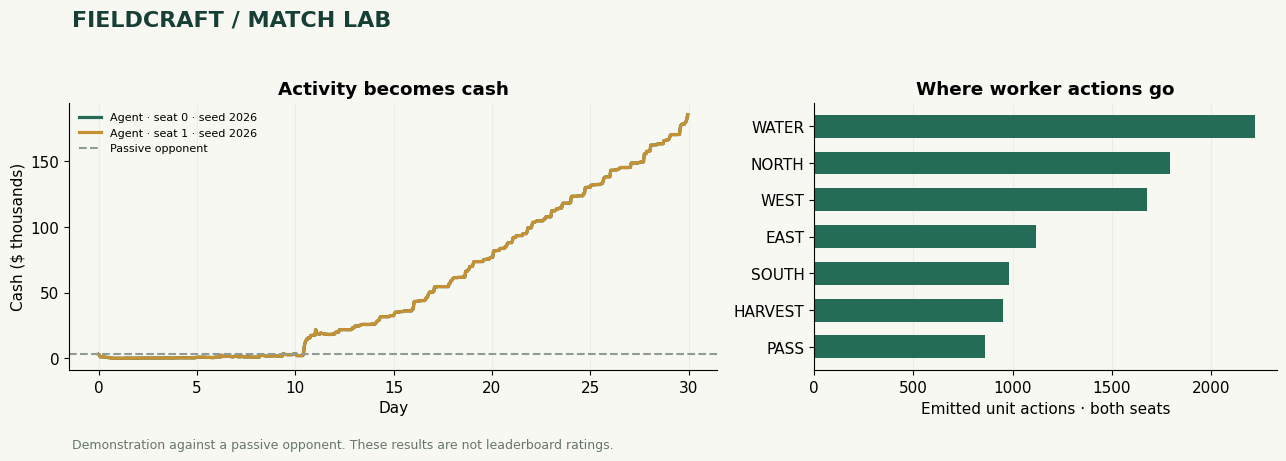

In [6]:
if LAB_READY:
    plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':11, 'axes.spines.top':False,
                         'axes.spines.right':False, 'axes.titleweight':'bold'})
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios':[1.4,1]})
    fig.patch.set_facecolor('#f7f8f2')
    trace = pd.DataFrame(traces)
    for (seed, seat), frame in trace.groupby(['seed','seat']):
        axes[0].plot(frame.step/24, frame.agent_cash/1000, label=f'Agent · seat {seat} · seed {seed}',
                     color=['#246b58','#c59132'][seat], linewidth=2.3)
    axes[0].axhline(summaries[0]['opponent_cash']/1000, color='#909b95', linestyle='--', label='Passive opponent')
    axes[0].set(title='Activity becomes cash', xlabel='Day', ylabel='Cash ($ thousands)')
    axes[0].legend(frameon=False, fontsize=8)
    common=action_counts.most_common(7)[::-1]
    axes[1].barh([x[0] for x in common], [x[1] for x in common], color='#246b58', height=.62)
    axes[1].set(title='Where worker actions go', xlabel='Emitted unit actions · both seats')
    for ax in axes:
        ax.set_facecolor('#f7f8f2'); ax.grid(axis='x', alpha=.14); ax.set_axisbelow(True)
    fig.suptitle('FIELDCRAFT / MATCH LAB', x=.06, ha='left', color='#173f35', fontsize=16, weight='bold')
    fig.text(.06,.005,'Demonstration against a passive opponent. These results are not leaderboard ratings.',color='#66766e',fontsize=9)
    fig.tight_layout(rect=[0,.04,1,.94])
    fig.savefig(ROOT/'match_lab.png', dpi=160, bbox_inches='tight')
    plt.show()

## 04 / Read the score honestly

| Evidence | Result | Interpretation |
|:--|:--|:--|
| Original Kaggle submission **56258004** | **2887.4** | Historical public rating, verified 21 September 2026 |
| Local packaging verification | See release checks below | Checks transformation and loading, not strength |
| Notebook match lab | Generated by this run | Functional demonstration against a passive opponent |

The original agent's rating can be checked by its owner with `kaggle competitions submissions -c kaggriculture -v`. [Kaggle's leaderboard](https://www.kaggle.com/competitions/kaggriculture/leaderboard) shows current team standings; it is not an archive of every historical submission score. A fresh submission starts its own match history, and the opposition changes over time.

The release manifest connects the score record to the original archive and records the compact source and distributed-file hashes. It is a provenance record, not an independent public attestation by Kaggle.

### Release checks

The minified agent matched the original agent on **2,876 actions across four complete games** (two seeds, both seats). All games completed, and a separate game passed through Kaggle's file-path loader. Tests used the pinned 1.32.7 engine. This is finite behavioral equivalence evidence, not proof over all possible states.

The audited source contains no credential, network, or file-access code. The publication bundle is built from an explicit file allowlist; private experiment logs, local paths, and private notebook or dataset references are excluded.

## 05 / Take the next useful step

For an experiment that teaches you something, replace the passive opponent with a reactive agent, run both seats over fresh seeds, and report wins, ties, and median cash margin separately. Change one mechanism at a time and keep a held-out set of seeds untouched.

If you find a reproducible failure, share the engine version, seed, player seat, and the first unexpected action. Those details make feedback actionable.

### Credits and license

This is an adapted release. Public route lineage includes **Ahmed Berat Ozer's V43** and **yhay81's shop-router series**. Retained upstream credits include thomastschinkel, destbreso, aurax7, tetsutani, prvsiyan, Dmitrii Gluzdov, and Rayk Kretzschmar. hakdevelopment contributed the release's control and market integration and this notebook. Public recorded play supplied the base route. Full notices and Apache-2.0 terms are included in the archive.

- [yhay81 · shop-router-0909](https://www.kaggle.com/code/yhay81/shop-router-0909)
- [yhay81 · shop-router-0911-simple](https://www.kaggle.com/code/yhay81/shop-router-0911-simple)
- [Ahmed Berat Ozer](https://www.kaggle.com/ahmedberatozer)
- [Kaggle Environments](https://github.com/Kaggle/kaggle-environments)
- [Competition rules](https://www.kaggle.com/competitions/kaggriculture/rules)

In [7]:
display(HTML('<div style="background:#102c28;color:#f7f8f2;padding:22px 26px;border-radius:12px;"><b style="font-size:22px;color:#efd08b;">Ready to run your own match.</b><p>Download the agent archive and keep the manifest with your results.</p></div>'))
display(FileLink('submission.tar.gz'))
display(FileLink('release_manifest.json'))
if LAB_READY:
    display(FileLink('demo_results.csv'))
    display(FileLink('match_lab.png'))

/kaggle/working/submission.tar.gz

/kaggle/working/release_manifest.json

/kaggle/working/demo_results.csv

/kaggle/working/match_lab.png